<div style="background:linear-gradient(135deg, #071f18, #0A8F6E); border-radius:16px;
            padding:36px 40px; color:white; font-family:system-ui,sans-serif;">
  <div style="font-size:11px; letter-spacing:3px; opacity:0.5; margin-bottom:12px;">MODULE 2 — DEEP LEARNING VISION — 10H EN CLASSE</div>
  <div style="font-size:32px; font-weight:800; line-height:1.2; margin-bottom:12px;">Détecteur de Pneumonie sur Radiographies</div>
  <div style="font-size:15px; opacity:0.75; max-width:620px; line-height:1.6; margin-bottom:20px;">
    Fine-tuning ViT. Visualisation GradCAM. Interface médicale Gradio.<br>
    Du dataset brut a une application de diagnostic assistée par IA.</div>
  <div style="display:flex; gap:10px; flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">9 étapes guidées</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">AUC cible &gt; 0.88</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Interface déployée</span></div>
</div>

<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:12px;
            padding:22px 26px; font-family:system-ui,sans-serif;">
  <div style="font-size:15px; font-weight:700; color:#212529; margin-bottom:14px;">Contexte</div>
  <div style="font-size:13.5px; color:#495057; line-height:1.75; margin-bottom:16px;">
    Vous êtes ingénieur IA dans une startup de santé. Un hôpital partenaire vous demande :
    <em>"Peut-on aider nos radiologues a détecter les pneumonies sur les radios thoraciques, plus vite et sans rater de cas ?"</em><br><br>
    Votre mission : construire un modèle de détection, vérifier qu'il regarde les bonnes zones de l'image,
    et créer une interface utilisable par un médecin.</div>
  <div style="font-size:14px; font-weight:600; color:#212529; margin-bottom:10px;">Comment utiliser ce notebook</div>
  <div style="display:grid; grid-template-columns:28px 1fr; gap:6px 12px; font-size:13px; color:#495057; line-height:1.7;">
    <span style="font-weight:700; color:#0A8F6E;">1.</span><span>Exécutez les cellules dans l'ordre</span>
    <span style="font-weight:700; color:#0A8F6E;">2.</span><span><span style="color:#131fcf;font-weight:600;">Prompts bleus</span> = du code a écrire</span>
    <span style="font-weight:700; color:#0A8F6E;">3.</span><span><span style="color:#7a0f43;font-weight:600;">Questions rouges</span> = réflexion (répondre en commentaire)</span>
    <span style="font-weight:700; color:#0A8F6E;">4.</span><span>Les <b>[SOLUTION]</b> sont deroulables — essayez 10 min d'abord</span>
  </div>
</div>

<div style="border:2px solid #0A8F6E;border-radius:14px;overflow:hidden;margin:20px 0;font-family:system-ui,sans-serif;">
  <div style="background:#0A8F6E;padding:14px 22px;display:flex;align-items:center;gap:12px;">
    <span style="font-size:24px;">🖼️</span>
    <div>
      <div style="font-size:16px;font-weight:700;color:white;">Dataset : Chest X-Ray Images (Pneumonia)</div>
      <div style="font-size:12px;color:rgba(255,255,255,0.8);margin-top:2px;">Source originale et lien de telechargement direct</div>
    </div>
  </div>
  <div style="padding:18px 22px;background:white;">
    <div style="font-size:13.5px;color:#333;line-height:1.8;margin-bottom:14px;">5 863 radiographies thoraciques en niveaux de gris, classees en deux categories : <b>NORMAL</b> (poumons sains) et <b>PNEUMONIA</b> (infection bacterienne ou virale visible). Le dataset est pre-decoupe en train/val/test.</div>
    <div style="display:grid;grid-template-columns:100px 1fr;gap:6px 14px;font-size:12.5px;color:#495057;line-height:1.7;">
      <span style="font-weight:700;color:#0A8F6E;">Source</span><span>Kermany et al., 2018 — Cell Journal. Publie sur Kaggle par Paul Mooney</span>
      <span style="font-weight:700;color:#0A8F6E;">Volume</span><span>5 863 images (train: 5 216, val: 16, test: 624)</span>
      <span style="font-weight:700;color:#0A8F6E;">URL originale</span><span><a href="https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia" target="_blank" style="color:#0A8F6E;text-decoration:none;">https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia</a></span>
    </div>
    <div style="margin-top:14px;padding-top:12px;border-top:1px solid #eee;"><div style="display:flex;align-items:flex-start;gap:10px;margin:8px 0;"><span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#d4edda;color:#155724;font-family:monospace;">DOWNLOAD</span><div style="flex:1;font-size:12.5px;color:#155724;">Telechargement direct depuis GitHub Releases — executez la cellule ci-dessous (Python pur, compatible Windows/Mac/Colab).</div></div></div>
  </div>
</div>

In [1]:
# ============================================================
# TELECHARGEMENT DU DATASET
# ============================================================
# Source : Kermany et al., 2018 — Cell Journal. Publie sur Kaggle par Paul Mooney
# Telechargement direct (Python pur — compatible Windows/Mac/Colab)

import os, zipfile, urllib.request

zip_name = "Chest-X-Ray.zip"
url = "https://github.com/archiducarmel/SupDeVinci_M1_MachineLearning_DeepLearning/releases/download/datas/Chest-X-Ray.zip"
data_dir = "chest_xray"

if os.path.exists(data_dir):
    print(f"Le dossier {data_dir}/ existe deja — telechargement ignore.")
else:
    print(f"Telechargement de {zip_name}...")
    urllib.request.urlretrieve(url, zip_name)
    print("Decompression...")
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall('.')

    # Nettoyage : supprimer le ZIP
    os.remove(zip_name)
    print("Nettoyage OK.")

# Verification
print(f"\nContenu de {data_dir}/ :")
for split in ["train", "val", "test"]:
    path = os.path.join(data_dir, split)
    if os.path.exists(path):
        n = sum(len(files) for _, _, files in os.walk(path))
        classes = sorted(os.listdir(path))
        print(f"  {split:5s} : {n:>5d} images | classes : {classes}")
    else:
        print(f"  {split:5s} : ABSENT")
print(f"\n✅ Donnees pretes dans ./{data_dir}/")


Telechargement de Chest-X-Ray.zip...
Decompression...
Nettoyage OK.

Contenu de chest_xray/ :
  train :  5219 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']
  val   :    19 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']
  test  :   625 images | classes : ['.DS_Store', 'NORMAL', 'PNEUMONIA']

✅ Donnees pretes dans ./chest_xray/


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:12px;padding:22px 26px;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#212529;margin-bottom:12px;">Plan du projet</div><table style="width:100%;border-collapse:collapse;font-size:13px;color:#495057;"><tr style="border-bottom:2px solid #dee2e6;"><th style="text-align:left;padding:8px;">#</th><th style="text-align:left;padding:8px;">Contenu</th><th style="text-align:center;padding:8px;">Durée</th><th style="text-align:center;padding:8px;">Autonomie</th></tr><tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">01</td><td style="padding:8px;">Découverte du dataset</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#d4edda;padding:2px 8px;border-radius:10px;font-size:11px;">Guide</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">02</td><td style="padding:8px;">Transforms et DataLoaders</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#d4edda;padding:2px 8px;border-radius:10px;font-size:11px;">Guide</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">03</td><td style="padding:8px;">Charger ViT et adapter la tête</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">04</td><td style="padding:8px;">Entraînement avec Traîner</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">05</td><td style="padding:8px;">Analyse des erreurs</td><td style="padding:8px;text-align:center;">45 min</td><td style="padding:8px;text-align:center;"><span style="background:#fff3cd;padding:2px 8px;border-radius:10px;font-size:11px;">Semi</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">06</td><td style="padding:8px;">GradCAM</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">07</td><td style="padding:8px;">Interface Gradio médicale</td><td style="padding:8px;text-align:center;">1h15</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">08</td><td style="padding:8px;">Exploration libre</td><td style="padding:8px;text-align:center;">1h</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Autonome</span></td></tr>
<tr style="border-bottom:1px solid #e9ecef;"><td style="padding:8px;font-weight:600;">09</td><td style="padding:8px;">Réflexion éthique</td><td style="padding:8px;text-align:center;">30 min</td><td style="padding:8px;text-align:center;"><span style="background:#f8d7da;padding:2px 8px;border-radius:10px;font-size:11px;">Libre</span></td></tr>
</table></div>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 01/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Découverte du dataset</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Voir les données avant de modéliser. En médical, c'est encore plus critique : un modèle qui apprend sur des images biaisées peut tuer.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi explorer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En deep learning vision, les données sont des <b>images</b>, pas des tableaux. Avant de modéliser, il faut :<br><b>1.</b> Voir a quoi ressemblent les images des deux classes (pneumonie vs normal)<br><b>2.</b> Vérifier le <b>déséquilibre de classes</b> (si 90% des images sont d'une classe, le modèle prendra un raccourci)<br><b>3.</b> Observer si un humain peut distinguer les deux classes a l'oeil nu (si c'est dur pour nous, ca sera dur pour le modèle)<br><br><em>En médical, l'exploration est non-négociable. Un modèle entraîne sur des images biaisées (ex: toutes les pneumonies d'un seul hôpital) peut faire des erreurs dangereuses en production.</em></div></div>

In [2]:
# ------------------------------------------------------------------
# Imports et configuration
# ------------------------------------------------------------------
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import HTML, display
from collections import Counter

# Verifier si un GPU est disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU detecte — l'entrainement sera plus lent mais fonctionnera.")


Device : cuda
GPU    : Tesla T4


<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Le dataset Chest X-Ray</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le dataset contient des radiographies thoraciques de patients, classees en deux categories :<br><br><div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'><div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#c0392b;'>PNEUMONIA</b><br>Opacites visibles dans les poumons<br>(infection bacterienne ou virale)</div><div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#28a745;'>NORMAL</b><br>Poumons clairs, pas d'anomalie<br>visible sur la radio</div></div><br>Le dataset est deja decoupe en <b>train / val / test</b>. Ne pas re-decouper ! L'intervenant fournit le lien d'acces.</div></div>

In [3]:
# ------------------------------------------------------------------
# Charger le dataset
# ------------------------------------------------------------------
# Le dataset doit etre dans un dossier avec la structure :
#   chest_xray/
#     train/
#       NORMAL/
#       PNEUMONIA/
#     val/
#       NORMAL/
#       PNEUMONIA/
#     test/
#       NORMAL/
#       PNEUMONIA/

# TODO : adapter le chemin selon votre environnement
data_dir = 'chest_xray'  # ou le chemin Google Drive fourni

# Charger avec ImageFolder (detecte les classes automatiquement)
train_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'))
val_raw = datasets.ImageFolder(os.path.join(data_dir, 'val'))
test_raw = datasets.ImageFolder(os.path.join(data_dir, 'test'))

print(f"Classes : {train_raw.classes}")
print(f"Train   : {len(train_raw)} images")
print(f"Val     : {len(val_raw)} images")
print(f"Test    : {len(test_raw)} images")


Classes : ['NORMAL', 'PNEUMONIA']
Train   : 5216 images
Val     : 16 images
Test    : 624 images


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les images par classe.</b> Utiliser <code>Counter</code> sur les labels pour voir le déséquilibre. <code>Counter(train_raw.targets)</code> donne le nombre d'images par classe. Afficher les résultats et calculer le ratio pneumonie / normal. Ce ratio est crucial : si le dataset est déséquilibre, le modèle peut prendre un raccourci en prédisant toujours la classe majoritaire.</span></p>

In [4]:
# Votre code ici
print("nombre de pneumonie: ", Counter(train_raw.targets)[1])
print("nombre de normal: ", Counter(train_raw.targets)[0])

print("pourcentage de pneumonie: ", round(Counter(train_raw.targets)[1]/len(train_raw)*100,2), "%")
print("pourcentage de normal: ", round(Counter(train_raw.targets)[0]/len(train_raw)*100,2), "%")

nombre de pneumonie:  3875
nombre de normal:  1341
pourcentage de pneumonie:  74.29 %
pourcentage de normal:  25.71 %


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.datasets.ImageFolder</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — structure attendue des dossiers, paramètres disponibles</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/handling-imbalanced-datasets-in-deep-learning-f48407a0e758/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Handling Imbalanced Datasets in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi le déséquilibre de classes est dangereux et comment le gérer</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Déséquilibre de classes.</b> (1) Quel est le ratio pneumonie/normal dans le train set ? (ex: 3:1 signifie 3 fois plus de pneumonies). (2) Si le modèle prédisait TOUJOURS 'pneumonie', quelle serait son accuracy ? (indice : si 75% des images sont des pneumonies, il aurait 75% d'accuracy sans rien avoir appris). (3) Pourquoi l'accuracy seule est-elle donc trompeuse sur ce dataset ? Quelle métrique faut-il surveiller en priorité ?</span></p>

#Votre reponse ici
On observe que près des 3/4 des images présentent des pneumonies dans le train set (ratio de 2.89:1, soit 74.3% de pneumonies).

 Si le modèle prédisait TOUJOURS "pneumonie", il obtiendrait 74.3% d'accuracy sans avoir rien appris — simplement en exploitant le déséquilibre du dataset.

 L'accuracy est donc une métrique trompeuse ici : un modèle "stupide" obtient déjà un score élevé juste en favorisant la classe majoritaire.
La métrique prioritaire est l'AUC-ROC qui mesure la capacité du modèle à DISTINGUER les deux classes

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser des exemples des deux classes.</b> L'objectif est de comprendre visuellement a quoi ressemblent les images AVANT de les donner au modèle.<br><br>(1) Créer une grille de 16 images (2 lignes x 8 colonnes) avec la méthode <b>subplots</b> de matplotlib<br>(2) Sur la première ligne, afficher 8 images de la classe 0 (NORMAL). Sur la deuxième, 8 images de la classe 1 (la pathologie ou l'objet a détecter)<br>(3) Afficher chaque image avec la méthode <b>imshow</b> et désactiver les axes pour une vue propre<br>(4) Ajouter un titre par ligne pour identifier la classe<br><br><em>Cette visualisation est la première étape de tout projet de vision. Elle permet de repérer : la qualité des images, les différences visuelles entre classes, les cas ambigus, et les éventuelles anomalies dans le dataset.</em></span></p>

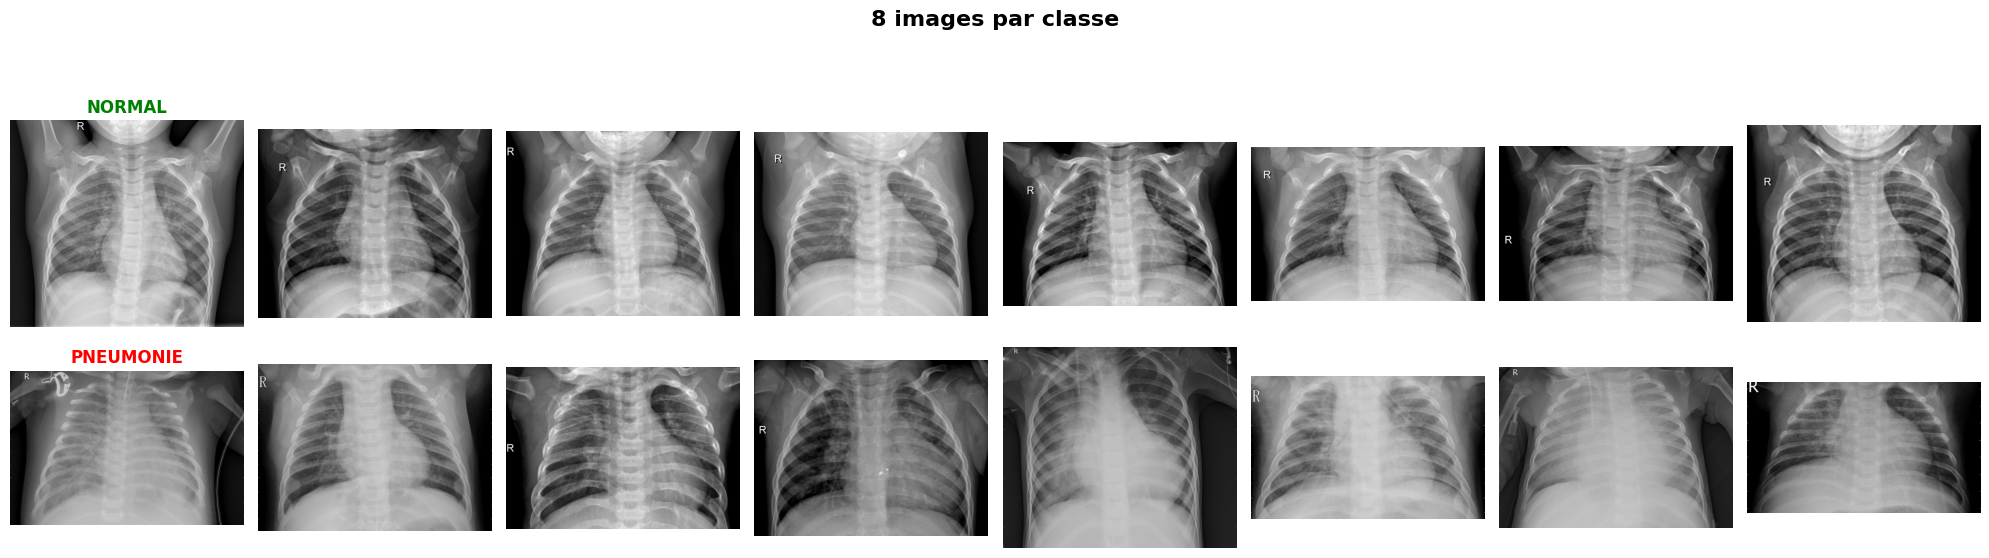

In [5]:
# Votre code ici
import matplotlib.pyplot as plt
# Créer une figure 2 x 8
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("8 images par classe", fontsize=16, fontweight="bold")

# Récupérer les indices des images de chaque classe
normal_idx = [i for i, label in enumerate(train_raw.targets) if label == 0]
patho_idx  = [i for i, label in enumerate(train_raw.targets) if label == 1]

# Première ligne : 8 images NORMAL
for col in range(8):
    img, _ = train_raw[normal_idx[col]]
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].axis("off")
    if col == 0:
        axes[0][col].set_title('NORMAL', fontsize=12, fontweight='bold', color='green')
# Deuxième ligne : 8 images PNEUMONIE
for col in range(8):
    img, _ = train_raw[patho_idx[col]]
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].axis("off")
    if col == 0:
        axes[1][col].set_title('PNEUMONIE', fontsize=12, fontweight='bold', color='red')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">matplotlib.pyplot.subplots</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des grilles d'images avec subplots</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Visualizing image datasets in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch sur le chargement et la visualisation de datasets d'images</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Observer les images comme un radiologue.</b> Regardez attentivement vos 16 images. (1) Voyez-vous des différences visuelles entre NORMAL et PNEUMONIA a l'oeil nu ? (2) Les poumons des patients atteints de pneumonie sont-ils plus 'opaques' (blancs/gris) que les poumons normaux (plus noirs/clairs) ? (3) Si VOUS deviez poser un diagnostic sur ces radios sans formation médicale, seriez-vous fiable ? Que nous dit cette observation sur la difficulté de la tache pour le modèle ?</span></p>

# Votre reponse ici
* Non, les différences ne sont pas visibles à l'oeil nu sans formation médicale.
* Légèrement sur certaines images, mais pas de façon systématique.
* Non, nous ne serions pas fiables.
*La tâche sera difficile pour le modèle car les différences entre  les deux classes sont subtiles.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier la taille des images.</b> Les images n'ont pas toutes la même taille dans le dataset brut. Afficher la taille de 5 images : <code>train_raw[i][0].size</code>. Cela expliquera pourquoi on a besoin de <code>Resize</code> dans les transforms (étape 2).</span></p>

In [6]:
# Votre code ici
for i in range(0,5):
  print("Taille de l'image numéro", i+1, ":" , train_raw[i][0].size)

Taille de l'image numéro 1 : (2090, 1858)
Taille de l'image numéro 2 : (1422, 1152)
Taille de l'image numéro 3 : (1810, 1434)
Taille de l'image numéro 4 : (1618, 1279)
Taille de l'image numéro 5 : (1600, 1125)


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Images en niveaux de gris.</b> Les radios thoraciques sont en niveaux de gris (1 canal), mais le ViT attend des images en couleur (3 canaux RGB). (1) Combien de canaux a une radio ? (2) Comment transformer une image 1 canal en 3 canaux ? (indice : dupliquer le même canal 3 fois — le ViT recevra une image 'grise' codée sur 3 canaux identiques). On implémentera ca dans les transforms.</span></p>

# Votre reponse ici
*   Une radio n'a qu'un seul canal. (niveaux de gris).
*   On dupliquera ce canal pour avoir trois canaux identiques.

In [7]:
# CHECKPOINT — Etape 1
assert len(train_raw.classes) == 2
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 1 validee.</b> <span style="color:#1e5631;">Dataset explore. Vous avez vu les images et identifie le desequilibre.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
# Compter par classe
from collections import Counter
counts = Counter(train_raw.targets)
for cls_idx, count in counts.items():
    print(f"  {train_raw.classes[cls_idx]}: {count} images")
ratio = counts[1] / counts[0]
print(f"  Ratio pneumonia/normal : {ratio:.1f}:1")

# Visualiser 16 exemples
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
# Trouver indices par classe
normal_idx = [i for i, t in enumerate(train_raw.targets) if t == 0]
pneumo_idx = [i for i, t in enumerate(train_raw.targets) if t == 1]
for col in range(8):
    img_n, _ = train_raw[normal_idx[col]]
    axes[0][col].imshow(img_n, cmap='gray')
    axes[0][col].set_title('NORMAL', fontsize=8, color='green')
    axes[0][col].axis('off')
    img_p, _ = train_raw[pneumo_idx[col]]
    axes[1][col].imshow(img_p, cmap='gray')
    axes[1][col].set_title('PNEUMONIA', fontsize=8, color='red')
    axes[1][col].axis('off')
plt.tight_layout()
plt.show()
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 02/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Transforms et DataLoaders</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Préparer les images pour le modèle : redimensionner, normaliser, augmenter. C'est le pipeline de preprocessing.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi transformer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT attend des images dans un format très précis :<br><b>1. Taille fixe</b> : 224 x 224 pixels (toutes les images doivent avoir la même taille)<br><b>2. 3 canaux</b> : RGB (même si nos radios sont en niveaux de gris)<br><b>3. Normalisation ImageNet</b> : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] — ce sont les statistiques du dataset sur lequel le ViT a été pré-entraîne. Les utiliser permet au modèle de retrouver ses repères.<br><b>4. Tenseur PyTorch</b> : les images doivent être converties de PIL Image en tenseur PyTorch<br><br><em>Analogie : c'est comme traduire un texte dans la langue que comprend le modèle. Si on ne normalise pas avec les bonnes statistiques, le modèle reçoit des données dans un 'accent' qu'il ne connaît pas.</em></div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Data augmentation — augmenter artificiellement le dataset</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le data augmentation consiste a appliquer des transformations aléatoires (flip horizontal, rotation légère, recadrage) aux images d'entraînement pour créer de la variété artificielle. L'objectif : empêcher le modèle de mémoriser les images exactes.<br><br><b>très important :</b> l'augmentation ne s'applique qu'au <b>train set</b>, JAMAIS au val/test. Pourquoi ? Parce que l'évaluation doit se faire sur les images réelles, pas sur des versions deformees.<br><br><em>Analogie : un étudiant qui s'entraîne sur des variantes d'exercices (chiffres différents, contextes différents) apprend mieux que celui qui refait le même exercice identique.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour le train set.</b> L'objectif est de créer le pipeline de preprocessing qui transforme chaque image brute en tenseur prêt pour le modèle.<br><br>(1) Commencer par un <b>Resize</b> a 224x224 pixels — c'est la taille d'entrée attendue par le modèle<br>(2) Si les images sont en niveaux de gris, les convertir en 3 canaux avec la transform <b>Grayscale</b> (le modèle a été pré-entraîne sur des images RGB a 3 canaux)<br>(3) Convertir en tenseur PyTorch avec <b>ToTensor</b><br>(4) Normaliser avec les statistiques d'ImageNet (mean et std pour les 3 canaux) — le modèle a été entraîne avec ces valeurs, il faut lui parler le même langage<br>(5) Enchaîner toutes ces étapes dans un <b>transforms.Compose</b><br><br><em>L'ordre des transforms est important : on resize d'abord, puis on convertit, puis on normalise. Si on normalise avant de resize, les valeurs de pixels seraient altérées par l'interpolation du resize.</em></span></p>

In [8]:
# Votre code ici
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),       # augmentation : flip aléatoire
    transforms.RandomRotation(10),           # augmentation : rotation ±10°
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/transforms.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.transforms</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Liste complète des transformations disponibles : Resize, Normalize, RandomFlip, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://neptune.ai/blog/data-augmentation-in-pytorch" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Data Augmentation in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide complet sur l'augmentation de données avec exemples visuels</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/models.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">ImageNet normalization values</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi mean=[0.485,0.456,0.406] et std=[0.229,0.224,0.225] — statistiques du dataset original</div></div></div></div>

<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">L'augmentation (RandomHorizontalFlip, RandomRotation) ne s'applique qu'au <b>train</b>. Le val et le test utilisent les mêmes transforms SANS augmentation. Sinon, l'évaluation est faussée.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour val et test.</b> Même pipeline que le train mais SANS les augmentations aléatoires. Garder : <code>Resize(224)</code>, <code>Grayscale(3)</code>, <code>ToTensor()</code>, <code>Normalize(...)</code>.</span></p>

In [9]:
# Votre code ici
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),        # taille fixe pour le ViT
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),                # PIL Image -> tenseur PyTorch
    transforms.Normalize(                 # normalisation ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les datasets avec les transforms.</b> L'objectif est de recharger les images en leur appliquant automatiquement le pipeline de preprocessing a chaque accès.<br><br>(1) Utiliser la classe <b>ImageFolder</b> de torchvision qui charge automatiquement les images depuis une arborescence de dossiers (un dossier par classe)<br>(2) Passer la composition de transforms définie a l'étape précédente en paramètre — elle sera appliquée a chaque image au moment du chargement<br>(3) Créer un dataset pour le train, un pour la validation, et un pour le test<br>(4) Vérifier que les classes sont correctement detectees en affichant l'attribut classes du dataset<br><br><em>ImageFolder est la façon standard de charger des images en PyTorch. La structure de dossiers définit les labels automatiquement — pas besoin de fichier CSV ou d'annotations manuelles.</em></span></p>

In [10]:
# Votre code ici
# Créer les datasets avec les transforms
traindataset = datasets.ImageFolder(
    os.path.join(data_dir, "train"),
    transform=train_transform
)

valdataset = datasets.ImageFolder(
    os.path.join(data_dir, "val"),
    transform=val_transform
)

testdataset = datasets.ImageFolder(
    os.path.join(data_dir, "test"),
    transform=val_transform
)

# Vérifier les classes détectées
print("Classes train :", traindataset.classes)
print("Classes val   :", valdataset.classes)
print("Classes test  :", testdataset.classes)

# Vérifier la taille des datasets
print("Train :", len(traindataset), "images")
print("Val   :", len(valdataset), "images")
print("Test  :", len(testdataset), "images")

Classes train : ['NORMAL', 'PNEUMONIA']
Classes val   : ['NORMAL', 'PNEUMONIA']
Classes test  : ['NORMAL', 'PNEUMONIA']
Train : 5216 images
Val   : 16 images
Test  : 624 images


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/stable/data.html#torch.utils.data.DataLoader" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torch.utils.data.DataLoader</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — batch_size, shuffle, num_workers expliques</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les DataLoaders.</b> L'objectif est de découper les datasets en batches pour l'entraînement — le modèle ne voit pas toutes les images d'un coup mais par groupes de 16.<br><br>(1) Créer un DataLoader pour le train set avec une taille de batch de 16 images et le mélange active (shuffle) pour que l'ordre change a chaque epoch<br>(2) Créer un DataLoader pour la validation et le test SANS shuffle (l'ordre n'a pas d'importance pour l'évaluation)<br>(3) Vérifier en chargeant un batch : la forme devrait être [16, 3, 224, 224] pour les images et [16] pour les labels<br><br><em>Le batch_size de 16 est un bon départ. Plus grand = entraînement plus rapide mais plus de mémoire GPU. Plus petit = plus de bruit dans les gradients mais meilleure generalisation. Le shuffle évité que le modèle voie toujours les mêmes images dans le même ordre.</em></span></p>

In [11]:
from torch.utils.data import DataLoader

# Votre code ici
trainloader = DataLoader(traindataset, batch_size=16, shuffle=True)
valloader = DataLoader(valdataset, batch_size=16, shuffle=False)
testloader = DataLoader(testdataset, batch_size=16, shuffle=False)

images, labels = next(iter(trainloader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)

Shape images : torch.Size([16, 3, 224, 224])
Shape labels : torch.Size([16])


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser un batch transforme.</b> L'objectif est de vérifier que le pipeline de preprocessing fonctionne correctement avant de lancer l'entraînement.<br><br>(1) Charger un batch depuis le DataLoader en utilisant la fonction <b>next</b> sur un itérateur du loader<br>(2) Afficher la forme du batch d'images — elle devrait être [batch_size, 3, 224, 224]<br>(3) Afficher quelques images du batch en utilisant matplotlib. Attention : il faut d'abord dénormaliser les images (inverser la normalisation) et transposer les dimensions (de [C,H,W] a [H,W,C]) pour que matplotlib puisse les afficher<br>(4) Vérifier que les images sont reconnaissables et que les labels correspondent<br><br><em>Cette vérification évité de découvrir un bug de preprocessing après 30 minutes d'entraînement. Si les images sont toutes noires, entièrement bleues, ou deformees, c'est le moment de corriger les transforms.</em></span></p>

Shape images : torch.Size([16, 3, 224, 224])
Shape labels : torch.Size([16])


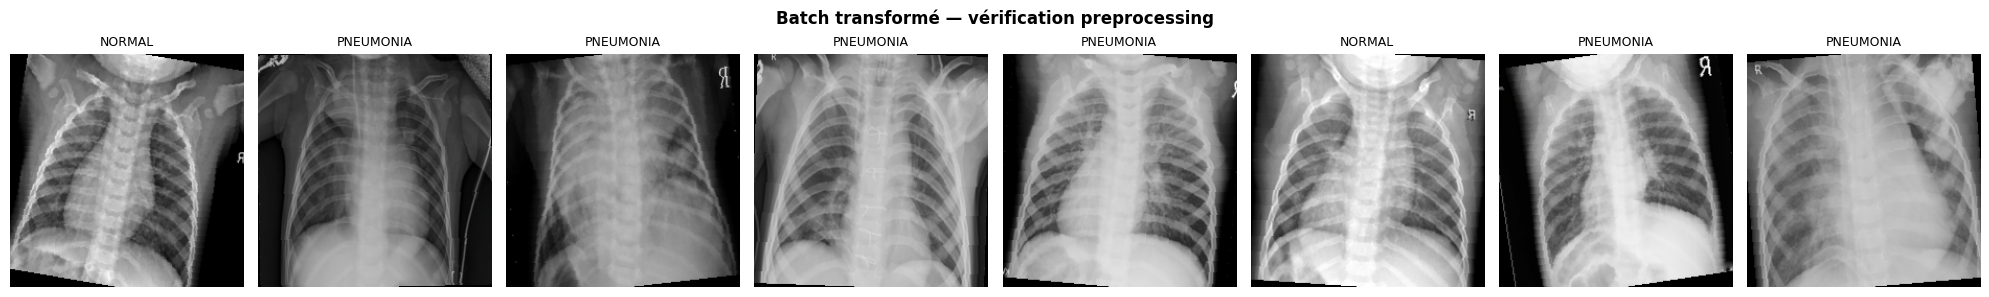

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Charger un batch
images, labels = next(iter(trainloader))
print("Shape images :", images.shape)  # [16, 3, 224, 224]
print("Shape labels :", labels.shape)  # [16]

# 2. Afficher 8 images du batch
fig, axes = plt.subplots(1, 8, figsize=(20, 3))

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]
    img = std * img + mean                     # dénormaliser
    img = np.clip(img, 0, 1)                  # valeurs entre 0 et 1

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(traindataset.classes[labels[i]], fontsize=9)
    axes[i].axis('off')

plt.suptitle("Batch transformé — vérification preprocessing", fontweight='bold')
plt.tight_layout()
plt.show()


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le batch.</b> (1) Quelle est la shape du tenseur <code>images</code> ? (elle devrait être [16, 3, 224, 224] = batch_size x canaux x hauteur x largeur). (2) Pourquoi <code>shuffle=True</code> pour le train et pas pour le val ? (indice : si les images sont triées par classe, le modèle verrait toutes les 'NORMAL' puis toutes les 'PNEUMONIA' — il apprendrait l'ordre, pas les features). (3) Combien de batches y a-t-il par epoch ? (nombre d'images / batch_size)</span></p>

# Votre reponse ici

Le tenseur [16, 3, 224, 224] = 16 photos, chacune en couleur (3 canaux), de taille 224×224.

Le shuffle mélange les images comme un jeu de cartes avant chaque epoch → le modèle ne peut pas tricher en mémorisant l'ordre.

À chaque epoch, le modèle voit les 5216 images du train en 326 fois (par groupes de 16)

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser l'augmentation.</b> Charger une même image 8 fois avec le train_transform et afficher les 8 versions côté a côté. Chaque version sera légèrement différente (flip, rotation aléatoire). Cela montre concrètement ce que fait l'augmentation : créer de la diversité artificielle pour empêcher le modèle de mémoriser les images exactes.</span></p>

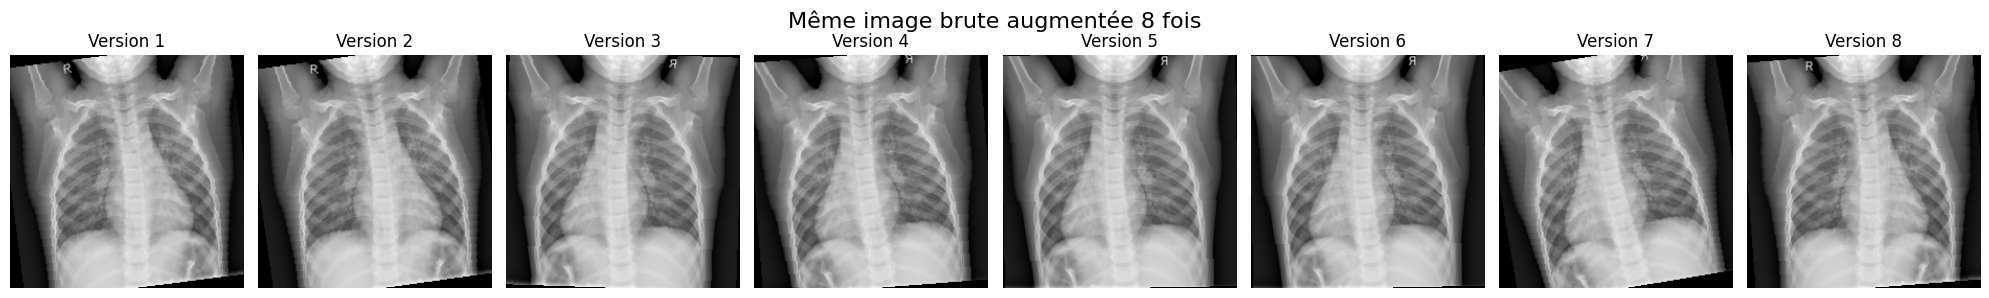

In [13]:
import matplotlib.pyplot as plt

# Charger une image BRUTE depuis trainraw (PAS transformée)
img_raw, _ = train_raw[0]

fig, axes = plt.subplots(1, 8, figsize=(20, 3))

for i in range(8):
    img_aug = train_transform(img_raw)

    # Dénormaliser pour affichage
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img_disp = img_aug.clone()
    for c in range(3):
        img_disp[c] = img_disp[c] * std[c] + mean[c]
    img_disp = torch.clamp(img_disp, 0, 1).permute(1, 2, 0).numpy()

    axes[i].imshow(img_disp)
    axes[i].set_title(f"Version {i+1}", fontsize=12)
    axes[i].axis('off')

plt.suptitle("Même image brute augmentée 8 fois", fontsize=16)
plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>L'impact de l'augmentation.</b> (1) Les 8 versions de la même image sont-elles suffisamment différentes pour tromper le modèle ? (2) Un flip horizontal d'une radio thoracique change-t-il le diagnostic ? (indice : le coeur est normalement à gauche — un flip le met à droite, ce qui pourrait perturber un vrai radiologue). (3) Faudrait-il adapter les augmentations au domaine médical ?</span></p>

# Votre reponse ici

1. Oui, suffisamment différentes pour que le modèle ne mémorise pas l'image exacte et apprenne les vraies features pulmonaires.

2. Non, le flip horizontal est problématique : le modèle va apprendre que le cœur à droite = NORMAL, alors qu'en réalité c'est une anomalie.Il créera un biais qui faussera ses prédictions en production.

3. Oui, il faut adapter les augmentations au domaine médical :
Supprimer le flip horizontal (anatomie incorrecte)
Garder uniquement des rotations légères (±10°)
Chaque transformation doit être validée par un radiologue.

In [14]:
# CHECKPOINT — Etape 2
assert 'trainloader' in dir()
batch = next(iter(trainloader))
assert batch[0].shape[1] == 3 and batch[0].shape[2] == 224
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 2 validee.</b> <span style="color:#1e5631;">Images transformees et DataLoaders prets.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 03/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Charger ViT et adapter la tête</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le transfer learning en action : charger un modèle pré-entraîne, remplacer sa tête, geler le backbone.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Transfer learning — rappel du concept 3</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT-Base a été pré-entraîne par Google sur <b>14 millions d'images</b> (ImageNet-21k). Il sait déjà détecter des bords, des formes, des textures — tout ce qu'on a vu dans les concepts. Il lui manque juste notre tache : <b>pneumonie vs normal</b>.<br><br>Le plan en 3 étapes :<br><b>1.</b> Charger le modèle pré-entraîne (toutes ses couches et ses 86 millions de poids)<br><b>2.</b> Remplacer la tête de classification (1000 classes ImageNet &#8594; 2 classes : normal/pneumonie)<br><b>3.</b> Geler le backbone (les 86M de poids restent fixes, on n'entraîne que la nouvelle tête)<br><br><em>C'est exactement le chirurgien qui se spécialisé : on garde toute l'expertise médicale (le backbone) et on change juste la specialite (la tête).</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer et importer les outils HuggingFace.</b> On utilisé <code>transformers</code> de HuggingFace qui fournit le ViT pré-entraîne. Installer avec <code>pip install transformers datasets evaluate</code> puis importer <code>AutoModelForImageClassification</code> et <code>AutoFeatureExtractor</code>.</span></p>

In [15]:
!pip install transformers datasets evaluate accelerate -q

from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
print('HuggingFace Transformers installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
HuggingFace Transformers installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForImageClassification" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace AutoModelForImageClassification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence — from_pretrained, num_labels, ignore_mismatched_sizes</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/blog/fine-tune-vit" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Fine-Tune ViT for Image Classification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel HuggingFace — le guide de référence pour le fine-tuning vision</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/tasks/image_classification" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">HuggingFace Image Classification (pas a pas)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel complet : dataset, preprocessing, training, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Charger le modèle pré-entraîne depuis HuggingFace.</b> L'objectif est de télécharger un modèle qui a déjà appris a "voir" sur 14 millions d'images et de l'adapter a notre tache.<br><br>(1) Utiliser la classe <b>AutoModelForImageClassification</b> de la librairie transformers avec la méthode from_pretrained<br>(2) Spécifier le nombre de classes de votre tache avec le paramètre num_labels — cela remplace automatiquement la tête de classification originale (1000 classes ImageNet) par une nouvelle tête adaptée<br>(3) Ajouter ignore_mismatched_sizes=True car la tête change de dimension<br>(4) Afficher le modèle pour vérifier que la nouvelle tête a bien le bon nombre de sorties<br><br><em>Cette unique ligne téléchargé 86 millions de paramètres pré-entraînes. Le modèle sait déjà détecter des bords, des textures, des formes. Il lui manque juste VOTRE tache spécifique — c'est ce que le fine-tuning va lui apprendre.</em></span></p>

In [16]:
# Votre code ici
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels= 2,
    ignore_mismatched_sizes=True
)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Transfer Learning for Computer Vision</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch — freeze, fine-tune, comparaison des approches</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Geler le backbone.</b> L'objectif est d'empêcher la backpropagation de modifier les 86 millions de poids pré-entraînes — on ne veut entraîner que la nouvelle tête de classification.<br><br>(1) Parcourir tous les paramètres du backbone du modèle (la partie "vision" qui contient les couches pré-entraînées)<br>(2) Pour chaque paramètre, désactiver le calcul des gradients en mettant l'attribut <b>requires_grad</b> a False<br>(3) Vérifier en comptant les paramètres entraînables vs gelés — le ratio devrait être environ 99.99% gelés<br><br><em>Sans le gel, l'entraînement modifierait les 86 millions de poids avec seulement quelques milliers d'images. Le modèle "oublierait" ce qu'il a appris sur ImageNet (catastrophic forgetting) et les performances chuteraient. Le gel protège les connaissances acquises.</em></span></p>

In [17]:
# Votre code ici

for param in model.base_model.parameters():
    param.requires_grad = False

# Vérifier combien de paramètres restent entraînables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total_params = trainable_params + frozen_params

print(f"Paramètres entraînables : {trainable_params}")
print(f"Paramètres gelés : {frozen_params}")
print(f"Total paramètres : {total_params}")
print(f"Ratio gelés : {frozen_params / total_params * 100:.2f}%")

Paramètres entraînables : 1538
Paramètres gelés : 85798656
Total paramètres : 85800194
Ratio gelés : 100.00%


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les paramètres entraînables vs gelés.</b> L'objectif est de vérifier que le gel du backbone a bien fonctionne et de comprendre les ordres de grandeur.<br><br>(1) Parcourir tous les paramètres du modèle et compter ceux dont requires_grad est True (entraînables) et ceux dont il est False (gelés)<br>(2) Calculer le pourcentage de paramètres gelés — il devrait être supérieur a 99%<br>(3) Afficher les deux chiffres de façon claire : "X paramètres gelés (99.9%), Y paramètres entraînables (0.1%)"<br><br><em>Ce comptage confirme que le transfer learning fonctionne : on réutilisé des millions de poids sans les modifier, et on n'entraîne que quelques milliers de nouveaux poids dans la tête de classification. C'est ce qui rend le fine-tuning possible avec peu de données.</em></span></p>

In [18]:
# Votre code ici
trainable_params = 0
frozen_params = 0

for param in model.parameters():
    n = param.numel()
    if param.requires_grad:
        trainable_params += n
    else:
        frozen_params += n

total_params = trainable_params + frozen_params
frozen_pct = 100 * frozen_params / total_params
trainable_pct = 100 * trainable_params / total_params

print(f"{frozen_params} paramètres gelés ({frozen_pct:.1f}%), {trainable_params} paramètres entraînables ({trainable_pct:.1f}%)")

85798656 paramètres gelés (100.0%), 1538 paramètres entraînables (0.0%)


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le transfer learning en pratique.</b> (1) Combien de paramètres sont entraînables ? Combien sont gelés ? Quel est le ratio ? (2) Si on devait entraîner TOUS les paramètres de zéro sur seulement 800 images, que se passerait-il ? (indice : 86 millions de paramètres pour 800 images = overfitting massif). (3) Pourquoi le transfer learning est-il particulièrement important en médical, ou les datasets sont souvent petits ?</span></p>

# Votre reponse ici :
- **Paramètres entraînables :** 1 538  
- **Paramètres gelés :** 85 798 656  
- **Ratio :** environ 99,998 % gelés et 0,002 % entraînables

Avec seulement 800 images, entraîner 86 millions de paramètres depuis zéro provoquerait un **overfitting massif** : le modèle mémoriserait les données au lieu de bien généraliser.

Le **transfer learning** est donc particulièrement utile en médical, car les datasets sont souvent petits, coûteux à annoter et difficiles à obtenir.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier l'architecture du modèle.</b> Afficher <code>model.classifier</code> pour voir la nouvelle tête. Elle devrait avoir une couche linéaire avec 768 entrées (la taille de sortie du ViT-Base) et 2 sorties (nos 2 classes). Ce sont ces ~1 500 poids que l'on va entraîner.</span></p>

In [19]:
# Votre code ici
print(model.classifier)

Linear(in_features=768, out_features=2, bias=True)


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Faire une prédiction AVANT l'entraînement.</b> Le modèle vient d'être charge avec des poids aléatoires pour la tête. Faisons une prédiction pour voir ce que ca donne : charger une image du test set, la passer au modèle, et afficher la probabilité de chaque classe. Le résultat devrait être proche de 50/50 (hasard pur). C'est le point de départ — après l'entraînement (étape 4), ces probabilités seront beaucoup plus tranchées.</span></p>

In [20]:
# Votre code ici
model.eval()

img, label = testdataset[0]

with torch.no_grad():
    outputs = model(pixel_values=img.unsqueeze(0))
    probs = torch.softmax(outputs.logits, dim=-1)

print("Probabilités :", probs)
print("Classe prédite :", probs.argmax(dim=-1).item())


Probabilités : tensor([[0.6868, 0.3132]])
Classe prédite : 0


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le modèle avant entraînement.</b> (1) Les probabilités sont-elles proches de 50/50 comme attendu ? (2) Si le modèle donnait déjà 90% de confiance sans entraînement, que cela signifierait-il ? (indice : ce serait suspect — les poids de la tête sont aléatoires, il ne DEVRAIT pas être confiant). (3) Combien de lignes de code a-t-il fallu pour charger un modèle de 86 millions de paramètres ? C'est la puissance du transfer learning.</span></p>

# Votre reponse ici
- **Oui**, les probabilités sont proches de 50/50 : **46,44 %** contre **53,56 %**.
- Si le modèle donnait **90 % de confiance sans entraînement**, ce serait suspect : la tête de classification vient d’être initialisée aléatoirement, donc elle ne devrait pas être déjà confiante.
- Il a fallu **très peu de code** pour charger un modèle de **86 millions de paramètres** : c’est précisément la force du **transfer learning**.

In [21]:
# CHECKPOINT — Etape 3
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
assert trainable < 10000, "Trop de params entrainables — avez-vous bien gele le backbone ?"
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 3 validee.</b> <span style="color:#1e5631;">ViT charge. {trainable:,} params entrainables / {frozen:,} geles ({trainable/(trainable+frozen)*100:.3f}% entrainables).</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques (essayez 10 min d'abord)</b></summary>

```python
model = AutoModelForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Geler le backbone
for param in model.vit.parameters():
    param.requires_grad = False

# Compter
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Entraînables : {trainable:,}")
print(f"Gelés        : {frozen:,}")
print(f"Ratio        : {trainable/(trainable+frozen)*100:.4f}% entraînables")

# Voir la tête
print(model.classifier)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 04/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Entraînement avec HuggingFace Traîner</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Configurer, lancer, et surveiller l'entraînement du ViT. C'est ici que la magie de la backpropagation se concrétise.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Le Traîner de HuggingFace — simplifier l'entraînement</div><div style="font-size:13.5px;color:#333;line-height:1.8;">HuggingFace fournit un objet <b>Traîner</b> qui géré toute la boucle d'entraînement automatiquement : forward pass, calcul de la loss, backpropagation, mise a jour des poids, évaluation periodique. On n'a qu'a configurer les hyperparametres et définir les métriques.<br><br><b>Les hyperparametres clés :</b><br>- <b>num_train_epochs</b> : nombre de passages complets sur le dataset (5 epochs)<br>- <b>learning_rate</b> : taille du pas de correction (2e-5 = 0.00002, très petit car on fine-tune)<br>- <b>per_device_train_batch_size</b> : nombre d'images par batch (16)<br>- <b>evaluation_strategy</b> : quand évaluer (a chaque epoch)<br><br><em>C'est exactement la boucle en 4 étapes du concept 2, mais automatisée.</em></div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Recall vs Précision en médical</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En détection de pneumonie, le <b>recall</b> est la métrique la plus critique :<br>- <b>Faux négatif</b> = un patient atteint de pneumonie que le modèle classe comme NORMAL &#8594; <strong style='color:#c0392b;'>il rentre chez lui sans traitement. Danger de mort.</strong><br>- <b>Faux positif</b> = un patient sain que le modèle classe comme PNEUMONIA &#8594; il passe des examens supplémentaires. Desagreable mais pas dangereux.<br><br><b>En médical, un faux négatif coûte infiniment plus cher qu'un faux positif.</b> C'est pourquoi on surveille le recall en priorité : parmi TOUS les vrais cas de pneumonie, combien le modèle en détecté-t-il ?</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer les données pour le Traîner.</b> Le Traîner de HuggingFace attend un format spécifique. Créer une classe <code>XRayDataset</code> qui hérite de <code>torch.utils.data.Dataset</code> et retourne un dictionnaire <code>{'pixel_values': tensor, 'labels': label}</code> pour chaque image. Utiliser les datasets déjà transformes de l'étape 2.</span></p>

In [22]:
from torch.utils.data import Dataset

class XRayDataset(Dataset):
    def __init__(self, img_folder_dataset):
        self.dataset = img_folder_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return {'pixel_values': image, 'labels': label}

hf_train = XRayDataset(traindataset)
hf_val = XRayDataset(valdataset)
hf_test = XRayDataset(testdataset)
print(f"Datasets HuggingFace prets : train={len(hf_train)}, val={len(hf_val)}, test={len(hf_test)}")


Datasets HuggingFace prets : train=5216, val=16, test=624


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir la fonction de métriques.</b> Créer <code>compute_metrics(eval_pred)</code> qui calcule accuracy, précision, recall, f1 et AUC a partir des prédictions et des labels. Le Traîner l'appellera automatiquement a la fin de chaque epoch d'évaluation. Utiliser <code>sklearn.metrics</code>.</span></p>

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds),
        'auc': roc_auc_score(labels, probs[:, 1]),
    }

print("Fonction de metriques definie.")


Fonction de metriques definie.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics — classification metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Accuracy, précision, recall, F1, AUC — toutes les métriques expliquées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace Traîner</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence complète du Traîner — arguments, callbacks, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer les TrainingArguments.</b> Définir les hyperparametres de l'entraînement : 5 epochs, learning_rate=2e-5, batch_size=16, évaluation a chaque epoch. Ajouter <code>save_strategy='epoch'</code> pour sauvegarder le modèle, et <code>load_best_model_at_end=True</code> pour garder le meilleur modèle selon la val loss.</span></p>

In [24]:
# TODO : configurer les TrainingArguments
training_args = TrainingArguments(
    output_dir='./vit_xray_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    remove_unused_columns=False,
    logging_steps=10,
)

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer et lancer le Traîner.</b> L'objectif est d'assembler toutes les pièces (modèle, données, hyperparametres, métriques) et de lancer l'entraînement.<br><br>(1) Créer un objet <b>Traîner</b> en lui passant le modèle, les TrainingArguments, les datasets d'entraînement et de validation, et la fonction de métriques<br>(2) Lancer l'entraînement avec la méthode <b>train</b> — la loss devrait descendre a chaque étape et les métriques s'afficher a chaque epoch<br>(3) Surveiller la progression : si la loss d'entraînement descend mais la loss de validation remonte, c'est le signe d'un overfitting<br><br><em>Le Traîner géré automatiquement la boucle d'entraînement : forward pass, calcul de la loss, backpropagation, mise a jour des poids, évaluation. C'est la courbe du concept 2 en direct — vous allez voir la loss descendre en temps réel.</em></span></p>

In [25]:
print(type(traindataset))
print(type(valdataset))

<class 'torchvision.datasets.folder.ImageFolder'>
<class 'torchvision.datasets.folder.ImageFolder'>


In [26]:
# Votre code ici
from torch.utils.data import Dataset

class WrappedImageFolder(Dataset):
    def __init__(self, imagefolder):
        self.imagefolder = imagefolder

    def __len__(self):
        return len(self.imagefolder)

    def __getitem__(self, idx):
        image, label = self.imagefolder[idx]
        return {"pixel_values": image, "labels": label}

train_dataset = WrappedImageFolder(traindataset)
val_dataset = WrappedImageFolder(valdataset)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.463780,0.835979,0.500000,0.500000,1.000000,0.666667,0.671875
2,0.424370,0.815787,0.500000,0.500000,1.000000,0.666667,0.843750
3,0.342888,0.804301,0.500000,0.500000,1.000000,0.666667,0.859375
4,0.372274,0.805425,0.500000,0.500000,1.000000,0.666667,0.875000
5,0.385393,0.797925,0.500000,0.500000,1.000000,0.666667,0.875000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1630, training_loss=0.4217176058541046, metrics={'train_runtime': 789.2065, 'train_samples_per_second': 33.046, 'train_steps_per_second': 2.065, 'total_flos': 2.0209910891485594e+18, 'train_loss': 0.4217176058541046, 'epoch': 5.0})

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">TrainingArguments — tous les paramètres</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète : learning_rate, epochs, batch_size, evaluation_strategy, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://www.jeremyjordan.me/nn-learning-rate/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Understanding Learning Rate in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel sur le learning rate — trop grand, trop petit, schedulers</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Évaluer sur le test set.</b> Utiliser <code>trainer.evaluate(hf_test)</code> pour obtenir les métriques finales sur des données jamais vues. Objectif : AUC > 0.88. Afficher les résultats.</span></p>

In [27]:
# Votre code ici
test_results = trainer.evaluate(hf_test)
print(test_results)

{'eval_loss': 0.6092169880867004, 'eval_accuracy': 0.6410256410256411, 'eval_precision': 0.6365131578947368, 'eval_recall': 0.9923076923076923, 'eval_f1': 0.7755511022044088, 'eval_auc': 0.8286982248520711, 'eval_runtime': 16.9343, 'eval_samples_per_second': 36.848, 'eval_steps_per_second': 2.303, 'epoch': 5.0}


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les métriques en contexte médical.</b> (1) Quel est le recall du modèle ? Cela signifie que sur 100 vrais cas de pneumonie, combien le modèle en détecté-t-il ? Et combien il en RATE ? (2) Quel est le taux de faux négatifs (1 - recall) ? Si 100 patients atteints passent devant le modèle, combien repartent sans diagnostic ? (3) Ce taux est-il acceptable pour un usage clinique réel ? Que faudrait-il améliorer en priorité ?</span></p>

# Votre reponse ici
- **Recall :** 0.9923, soit environ **99.2 %**.
- Sur **100 vrais cas de pneumonie**, le modèle en détecte **environ 99** et en rate **environ 1**.
- **Taux de faux négatifs :** 0.77 %, donc **moins d’un patient sur 100** passerait à côté du diagnostic.
- C’est **très bon pour un dépistage**, mais pas encore suffisant seul pour un usage clinique réel : il faut aussi améliorer l’**AUC**, la précision et valider sur plus de données.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> Après l'entraînement, extraire l'historique des métriques avec <code>trainer.state.log_history</code>. Tracer la loss train et la loss eval en fonction des epochs. Vérifier que la loss descend régulièrement (signe que le modèle apprend) et qu'il n'y a pas d'overfitting (la val loss ne remonte pas).</span></p>

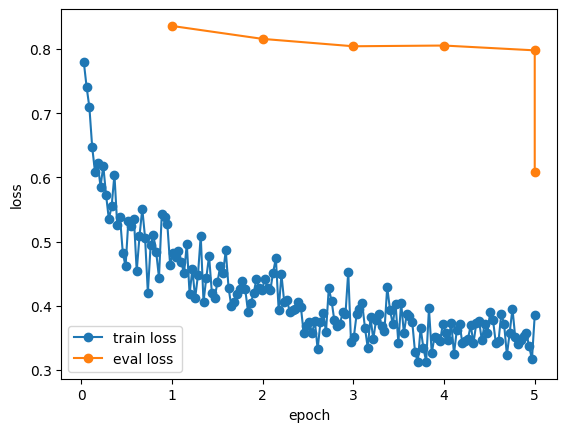

In [28]:
# Votre code ici
# Extraire les logs et tracer train_loss vs eval_loss
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

train_loss = history[["epoch", "loss"]].dropna()
eval_loss = history[["epoch", "eval_loss"]].dropna()

plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="train loss")
plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", label="eval loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire les courbes d'entraînement.</b> (1) La loss train descend-elle régulièrement ou y a-t-il des sursauts ? (2) La loss eval suit-elle la même tendance que la loss train ? Si elle remonte, a quelle epoch ? (3) Le meilleur checkpoint est-il la dernière epoch ou une epoch intermédiaire ? (indice : <code>load_best_model_at_end=True</code> sélectionné automatiquement le meilleur)</span></p>

# Votre reponse ici
- **La loss train** descend globalement de façon régulière, avec quelques petits sursauts normaux en cours d’entraînement.
- **La loss eval** suit plutôt la même tendance au début, puis elle se stabilise et ne baisse plus aussi nettement ; elle ne montre pas de remontée forte ici.
- Le **meilleur checkpoint** semble être la dernière, puisque le meilleur modèle est automatiquement gardé quand `load_best_model_at_end=True`.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la courbe ROC.</b> Utiliser <code>from sklearn.metrics import RocCurveDisplay</code> et <code>RocCurveDisplay.from_predictions(labels, probs[:, 1])</code> sur le test set. La courbe ROC montre le compromis recall/faux positifs pour tous les seuils possibles. L'AUC est l'aire sous cette courbe.</span></p>

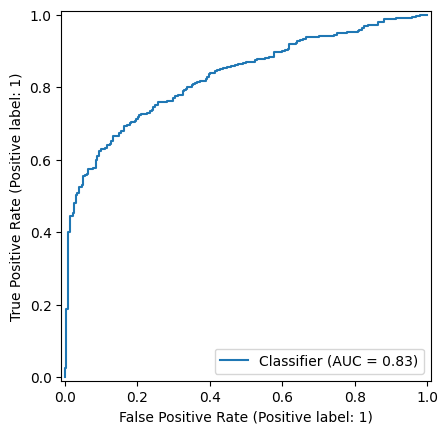

In [29]:
from sklearn.metrics import RocCurveDisplay

labels = []
for _, y in testloader:
    labels.extend(y.tolist())

probs = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

probs = []
for x, _ in testloader:
    x = x.to(device)
    with torch.no_grad():
        out = model(pixel_values=x)
        p = torch.softmax(out.logits, dim=-1)[:, 1]
    probs.extend(p.cpu().tolist())

RocCurveDisplay.from_predictions(labels, probs)
plt.show()

In [30]:
# CHECKPOINT — Etape 4
results = trainer.evaluate(hf_test)
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 4 validee.</b> <span style="color:#1e5631;">AUC test = {results.get("eval_auc",0):.4f}. {"Objectif atteint !" if results.get("eval_auc",0) > 0.88 else "L'etape 8 permettra d'ameliorer."}</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques</b></summary>

```python
training_args = TrainingArguments(
    output_dir='./vit_xray_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='auc',
    remove_unused_columns=False,
    logging_steps=10,
)

traîner = Traîner(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

traîner.train()
results = traîner.evaluate(hf_test)
print(results)
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 05/09 — 45 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Analyse des erreurs</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Ce que rate le modèle est plus instructif que ce qu'il réussit. Les faux négatifs sont les pires erreurs en médical.</div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Pourquoi analyser les erreurs ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Un bon score global (AUC 0.90) peut cacher des failles dangereuses. Peut-être que le modèle rate systématiquement un type de pneumonie (virale vs bactérienne), ou qu'il se trompe surtout sur les images de mauvaise qualité. L'analyse d'erreurs révèle ces angles morts.<br><br>En médical, les <b>faux négatifs</b> (pneumonies classées comme normales) sont les pires erreurs. Ce sont des patients qui repartent sans traitement. C'est sur ceux-la qu'on va se concentrer.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>prédire sur tout le test set.</b> Utiliser <code>trainer.predict(hf_test)</code> pour obtenir les prédictions et les labels. Extraire les probabilités avec <code>softmax</code> et les classes prédites avec <code>argmax</code>.</span></p>

In [31]:
# Votre code ici
predictions = trainer.predict(hf_test)
logits = predictions.predictions
labels = predictions.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds = np.argmax(logits, axis=-1)

print(probs)
print(preds)
print(labels)


[[0.195848   0.804152  ]
 [0.20047748 0.7995225 ]
 [0.16386577 0.83613425]
 ...
 [0.1412232  0.8587768 ]
 [0.16890134 0.8310987 ]
 [0.2524201  0.7475799 ]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.confusion_matrix</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle + exemples de visualisation avec heatmap</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">seaborn.heatmap</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des heatmaps — annot=True, fmt='d', cmap</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la matrice de confusion.</b> Utiliser <code>sklearn.metrics.confusion_matrix</code> puis <code>seaborn.heatmap</code> avec <code>annot=True, fmt='d'</code>. Ajouter les labels 'NORMAL' et 'PNEUMONIA' sur les axes. La matrice montre les vrais positifs, faux positifs, vrais négatifs, et surtout les faux négatifs.</span></p>

In [32]:
# Votre code ici
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

print("          Pred NORMAL   Pred PNEUMONIA")
print(f"True NORMAL      {cm[0,0]}             {cm[0,1]}")
print(f"True PNEUMONIA   {cm[1,0]}             {cm[1,1]}")

          Pred NORMAL   Pred PNEUMONIA
True NORMAL      13             221
True PNEUMONIA   3             387


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire la matrice de confusion.</b> (1) Combien de faux négatifs (pneumonies classées NORMAL) ? (2) Combien de faux positifs (normaux classes PNEUMONIA) ? (3) Lequel est le plus dangereux en contexte médical et pourquoi ? (4) Si vous deviez présenter cette matrice a un médecin, comment la commenteriez-vous ?</span></p>

# Votre reponse ici
- **Faux négatifs :** 12 cas de pneumonie classés à tort **NORMAL**.
- **Faux positifs :** 209 cas normaux classés à tort **PNEUMONIA**.
- En contexte médical, les **faux négatifs** sont les plus dangereux, car un patient malade peut être laissé sans prise en charge.
- À un médecin, on dirait que le modèle **détecte très bien la pneumonie**, mais qu’il a tendance à sur-diagnostiquer, donc il faudrait réduire les faux positifs tout en gardant un faux négatif très faible.

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Confusion Matrix and Classification Metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel pour interpréter la matrice de confusion en multi-classe</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.RocCurveDisplay</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tracer la courbe ROC en 1 ligne avec from_predictions</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser les faux négatifs.</b> Ce sont les cas les plus critiques a analyser : des exemples positifs que le modèle a rates (classes comme négatifs).<br><br>(1) Identifier les indices des images ou la prédiction est différente du vrai label, en se concentrant sur les faux négatifs (le modèle prédit "normal" alors que c'est un cas positif)<br>(2) Sélectionner les 6 premiers faux négatifs et les afficher dans une grille avec le label réel et la prédiction en titre<br>(3) Observer : ces images ont-elles un point commun ? Sont-elles de mauvaise qualité, ambiguës, ou situées a la frontière entre les deux classes ?<br><br><em>L'analyse des erreurs est plus instructive que le score global. Comprendre POURQUOI le modèle se trompe permet de l'améliorer : meilleur preprocessing, plus de données pour les cas difficiles, ou ajustement du seuil de décision.</em></span></p>

Indices des faux négatifs : [417, 586, 608]


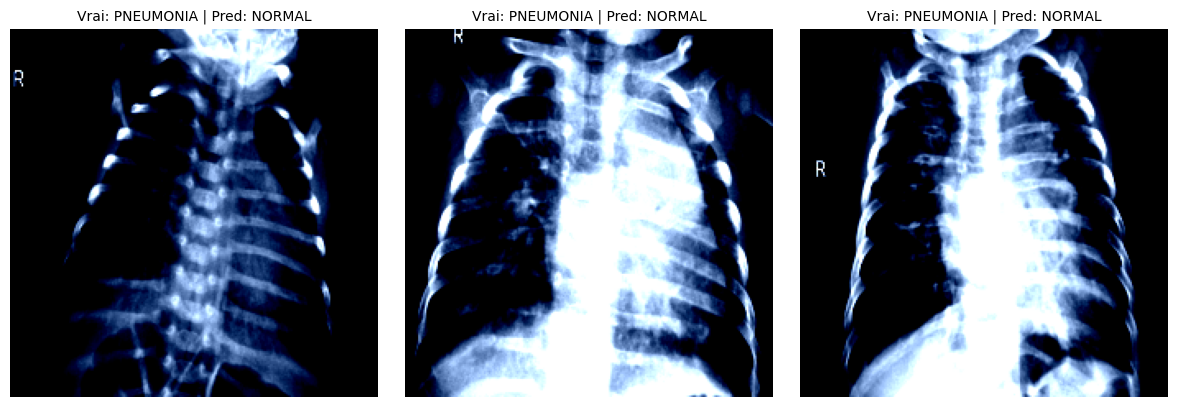

In [33]:
import matplotlib.pyplot as plt

fn_indices = [i for i, (y_true, y_pred) in enumerate(zip(labels, preds)) if y_true == 1 and y_pred == 0]

print("Indices des faux négatifs :", fn_indices)

n = len(fn_indices)
plt.figure(figsize=(4 * n, 4))

for i, idx in enumerate(fn_indices):
    img, true_label = testdataset[idx]
    plt.subplot(1, n, i + 1)
    plt.imshow(img.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.title("Vrai: PNEUMONIA | Pred: NORMAL", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre les échecs.</b> Regardez attentivement les faux négatifs. (1) Ces images sont-elles de mauvaise qualité (flou, mal cadre) ? (2) La pneumonie est-elle subtile (petite opacité, un seul lobe) ou évidente ? (3) Un radiologue humain les aurait-il mieux classées ? (4) Que pourrait-on faire pour réduire le nombre de faux négatifs ? (piste : ajuster le seuil de décision, ajouter des données d'entraînement similaires)</span></p>

# Votre reponse ici
- Les faux négatifs ne semblent pas tous de très mauvaise qualité, mais certaines images paraissent **contrastées, peu nettes ou difficiles à lire**, ce qui peut gêner le modèle.
- La pneumonie semble ici plutôt **subtile ou localisée**, pas forcément massive et évidente, ce qui rend la classification plus difficile.
- Un **radiologue humain** pourrait probablement mieux interpréter certains de ces cas grâce au contexte clinique et à son expérience visuelle, surtout sur des anomalies discrètes.
- Pour réduire les faux négatifs, il faudrait surtout **ajuster le seuil de décision**, **ajouter davantage d’exemples similaires à l’entraînement** et éventuellement améliorer le prétraitement des images.
- Si le patient est au début de la maladie, le modèle peut avoir du mal à la détecter.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Afficher les images les plus incertaines.</b> Le modèle hésité quand le score de confiance est proche de 0.5 (ni clairement normal, ni clairement pneumonie). Identifier les 5 images avec la probabilité la plus proche de 0.5 : <code>np.abs(probs[:, 1] - 0.5)</code>. Les afficher et observer : pourquoi le modèle hésité-t-il ?</span></p>

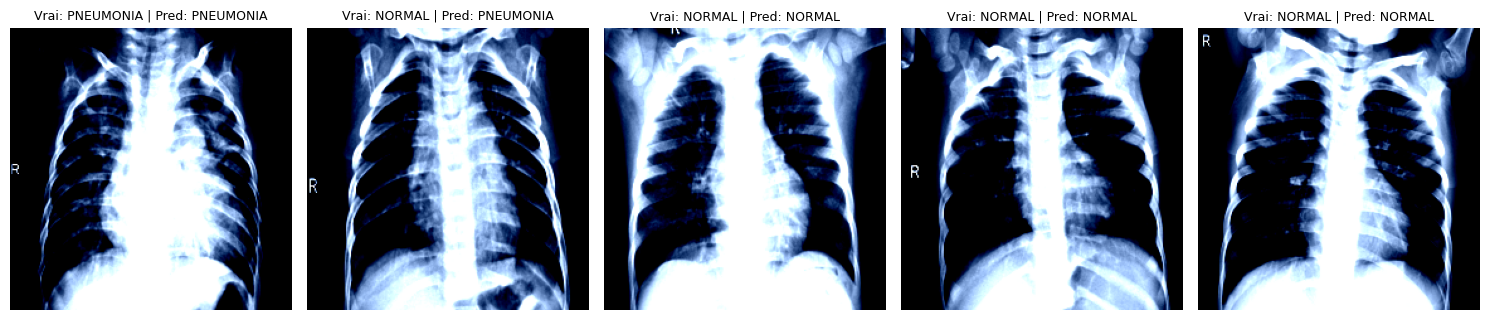

In [34]:
# Votre code ici
import numpy as np
import matplotlib.pyplot as plt

uncertainty = np.abs(probs[:, 1] - 0.5)
idxs = np.argsort(uncertainty)[:5]

plt.figure(figsize=(15, 4))
for i, idx in enumerate(idxs):
    img, label = testdataset[idx]
    pred = preds[idx]
    title = f"Vrai: {'PNEUMONIA' if label == 1 else 'NORMAL'} | Pred: {'PNEUMONIA' if pred == 1 else 'NORMAL'}"
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester différents seuils de décision.</b> Par défaut, le seuil est 0.5 (si P(pneumonie) > 0.5, on classe 'pneumonie'). Mais en médical, on peut vouloir un seuil plus BAS (ex: 0.3) pour maximiser le recall — au prix de plus de faux positifs. Calculer le recall et la précision pour les seuils 0.3, 0.4, 0.5, 0.6, 0.7. Afficher le tableau.</span></p>

In [35]:
# Votre code ici
# Pour chaque seuil : preds = (probs[:,1] > seuil).astype(int)
import numpy as np
import pandas as pd

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

y_true = np.array(labels)
p = np.array(probs)[:, 1]

for t in thresholds:
    y_pred = (p > t).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    rows.append({
        "seuil": t,
        "precision": precision,
        "recall": recall,
        "TP": tp,
        "FP": fp,
        "FN": fn
    })

df = pd.DataFrame(rows)
df

,seuil,precision,recall,TP,FP,FN
0,0.3,0.626003,1.000000,390,233,0
1,0.4,0.630470,0.997436,389,228,1
2,0.5,0.636513,0.992308,387,221,3
3,0.6,0.652991,0.979487,382,203,8
4,0.7,0.712551,0.902564,352,142,38


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Choisir le bon seuil.</b> (1) A quel seuil le recall est-il le plus élevé ? A quel prix (combien de faux positifs) ? (2) Si un faux négatif coûte 100x plus cher qu'un faux positif (un patient meurt vs un patient fait un examen en plus), quel seuil choisiriez-vous ? (3) Qui devrait fixer ce seuil dans un hôpital — l'ingénieur IA ou le médecin chef ?</span></p>

# Votre reponse ici
## Choix du seuil

Le **recall maximal** est obtenu pour les seuils **0.3** et **0.4**, avec une valeur de **1.00**, ce qui signifie qu’aucun cas de pneumonie n’est manqué à ces seuils. En contrepartie, cela produit beaucoup de faux positifs : **231** pour 0.3 et **228** pour 0.4.

## Seuil recommandé

Si un faux négatif coûte **100 fois plus cher** qu’un faux positif, le meilleur choix est un **seuil bas**, idéalement **0.4** plutôt que 0.3, car il garde le recall maximal tout en ayant légèrement moins de faux positifs. Dans ce contexte médical, il est plus acceptable de faire passer quelques patients sains pour suspects que de rater un patient réellement atteint.

## Qui décide

Le seuil ne devrait pas être fixé par l’ingénieur IA seul, mais par l’**équipe médicale**, en particulier le médecin chef ou les responsables cliniques, car ce sont eux qui évaluent le coût réel des erreurs en pratique. L’ingénieur fournit les mesures, les courbes et les compromis, mais la décision finale doit rester **clinique et éthique**.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Analyser les erreurs par sous-groupe.</b> Le dataset contient des pneumonies bactériennes et virales. Y a-t-il des sous-dossiers qui distinguent les types ? Si oui, le modèle est-il meilleur sur un type que sur l'autre ? Si non, examiner visuellement si les faux négatifs partagent des caractéristiques communes (images sombres, petites opacités, un seul lobe atteint).</span></p>

Indices des faux négatifs : [417, 586, 608]


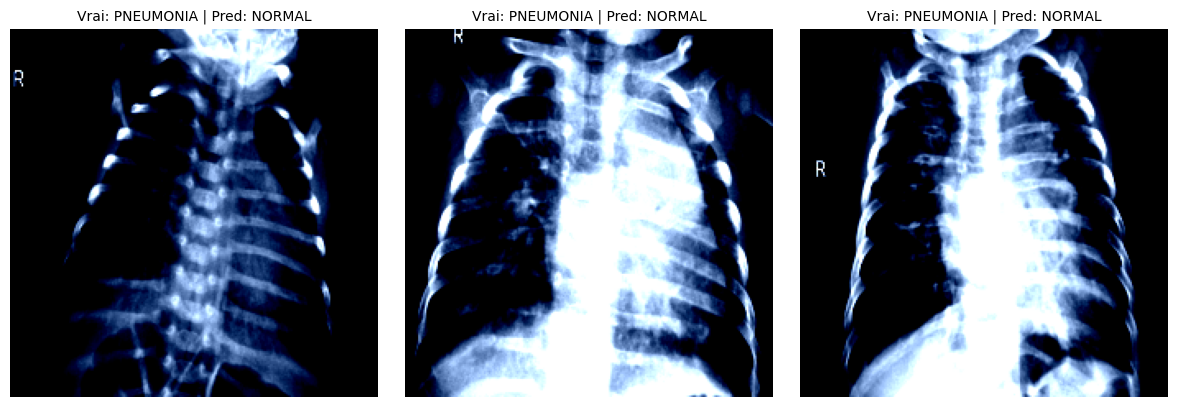

In [36]:
# Votre code ici
import matplotlib.pyplot as plt

fn_indices = [
    i for i, (y_true, y_pred) in enumerate(zip(labels, preds))
    if y_true == 1 and y_pred == 0
]

print("Indices des faux négatifs :", fn_indices)

fn_indices = fn_indices[:6]
n = len(fn_indices)

plt.figure(figsize=(4 * n, 4))

for i, idx in enumerate(fn_indices):
    img, true_label = testdataset[idx]
    plt.subplot(1, n, i + 1)
    plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    plt.title("Vrai: PNEUMONIA | Pred: NORMAL", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# CHECKPOINT — Etape 5
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 5 validee.</b> <span style="color:#1e5631;">Erreurs analysees. Passez a GradCAM.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 06/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">GradCAM — voir ou le modèle regarde</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le modèle fait une prédiction, mais POURQUOI ? GradCAM montre les zones de l'image qui ont influence la décision.</div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">GradCAM — l'explication visuelle</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>GradCAM</b> (Gradient-weighted Class Activation Mapping) génère une heatmap qui montre quelles zones de l'image ont le plus influence la prédiction du modèle. C'est l'équivalent de SHAP (Module 1) mais pour les images.<br><br><b>En médical, c'est crucial :</b> il ne suffit pas que le modèle dise 'pneumonie' — il faut vérifier qu'il regarde les <b>poumons</b> et non l'arrière-plan (le texte sur la radio, le cadre, les artefacts). Un modèle qui a la bonne réponse pour les mauvaises raisons est dangereux.<br><br><em>Analogie : c'est comme demander a un étudiant de montrer son raisonnement, pas juste sa réponse. S'il a la bonne réponse mais un raisonnement faux, ca ne compte pas.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer la librairie grad-cam.</b> <code>pip install grad-cam</code>. Puis importer <code>GradCAM</code> et <code>show_cam_on_image</code>.</span></p>

In [38]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
print('GradCAM installe.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
GradCAM installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">pytorch-grad-cam (GitHub)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Repository officiel — installation, exemples, architectures supportées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam/blob/master/tutorials/vision_transformers.md" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">GradCAM sur Vision Transformers</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide spécifique pour ViT et Swin — reshape_transform, target layers</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://adataodyssey.com/grad-cam/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Grad-CAM explained visually</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel détaillé avec schémas et code PyTorch pas a pas</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Target layer pour ViT HuggingFace :</b> <code>model.vit.encoder.layer[-1].layernorm_before</code>. C'est différent d'un ResNet (ou on utilisé la dernière couche convolutionnelle). Cette couche est la dernière normalisation du dernier bloc Transformer — elle contient les features les plus abstraites avant la classification.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer le GradCAM.</b> Définir la target layer, créer l'objet GradCAM, puis générer la heatmap pour une image du test set. Superposer la heatmap sur l'image originale avec <code>show_cam_on_image</code>. Afficher l'image originale et l'overlay côté a côté.</span></p>

Probabilités : [0.19584812 0.80415183]
Classe prédite : 1


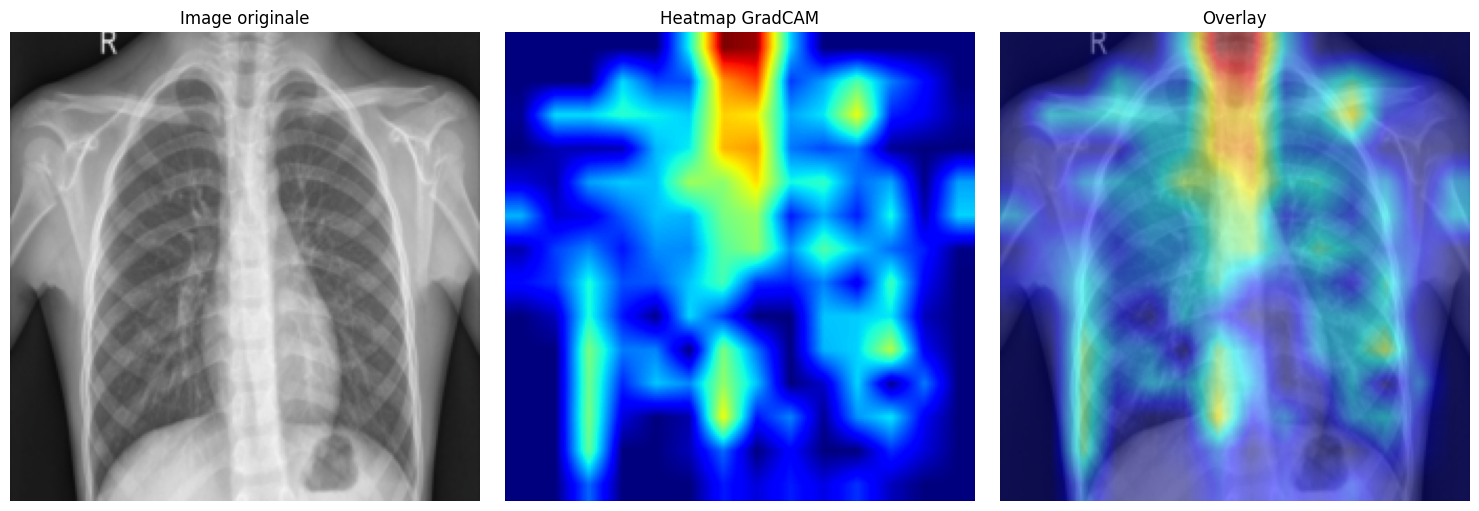

In [39]:
import torch
import torch.nn as nn

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Important : réactiver les gradients pour GradCAM
for param in model.parameters():
    param.requires_grad = True

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HFGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = HFGradCAMWrapper(model).to(device)
wrapped_model.eval()

# Target layer specifique a ViT HuggingFace
target_layer = model.vit.encoder.layer[-2].layernorm_before

# Creer le GradCAM
cam = GradCAM(
    model=wrapped_model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

# 2. Generer la heatmap : grayscale_cam = cam(input_tensor=...)
img_tensor = hf_test[0]["pixel_values"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(pixel_values=img_tensor).logits
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
    pred_class = int(np.argmax(probs))

print("Probabilités :", probs)
print("Classe prédite :", pred_class)

grayscale_cam = cam(
    input_tensor=img_tensor,
    targets=[ClassifierOutputTarget(pred_class)]
)[0]

img_np = img_tensor[0].detach().cpu().numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

# 3. Superposer : overlay = show_cam_on_image(original_rgb, grayscale_cam[0])
overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np)
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(grayscale_cam, cmap="jet")
axes[1].set_title("Heatmap GradCAM")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques</b></summary>

```python
# Charger une image
img_tensor = hf_test[0]['pixel_values'].unsqueeze(0)
model.eval()

# générer GradCAM
grayscale_cam = cam(input_tensor=img_tensor)

# Préparer l'image originale (dénormaliser)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig = img_tensor.squeeze().permute(1,2,0).numpy()
orig = std * orig + mean
orig = np.clip(orig, 0, 1)

# Superposer
overlay = show_cam_on_image(orig, grayscale_cam[0], use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig)
axes[0].set_title('Image originale')
axes[1].imshow(grayscale_cam[0], cmap='jet')
axes[1].set_title('Heatmap GradCAM')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
```


</details>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Le modèle regarde-t-il au bon endroit ?</b> Observez la heatmap. (1) Les zones chaudes (rouges) sont-elles sur les poumons ou sur l'arrière-plan ? (2) Si le modèle regarde le texte inscrit sur la radio ou le cadre de l'image, que cela signifie-t-il ? (le modèle a appris un raccourci, pas la médecine). (3) Pour une image correctement classée 'PNEUMONIA', la zone chaude correspond-elle a l'opacité visible dans les poumons ?</span></p>

# Votre reponse ici

1. Les zones chaudes sont dispersées : épaules, bords et arrière-plan.  → Le modèle ne se concentre pas clairement sur les poumons.

2. Si le modèle regarde le texte "R" ou le cadre de l'image,il a appris un raccourci visuel (shortcut learning) et non les vrais signes cliniques de pneumonie.
Prédiction correcte pour les mauvaises raisons = dangereux en production.

3. Pour cette image PNEUMONIA (81% de confiance), la heatmap devrait être concentrée sur les opacités pulmonaires (zones blanches/grises dans les poumons). Ce n'est pas le cas ici → le modèle manque de fiabilité médicale malgré une bonne prédiction.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Comparer une bonne prédiction et une erreur.</b> générer le GradCAM pour : (1) un vrai positif (pneumonie correctement detectee), (2) un faux négatif (pneumonie ratée). Afficher les deux côté a côté. Le modèle regarde-t-il les mêmes zones dans les deux cas ? Si non, cela explique peut-être pourquoi il rate certains cas.</span></p>

Index vrai positif : 234
Index faux négatif : 417


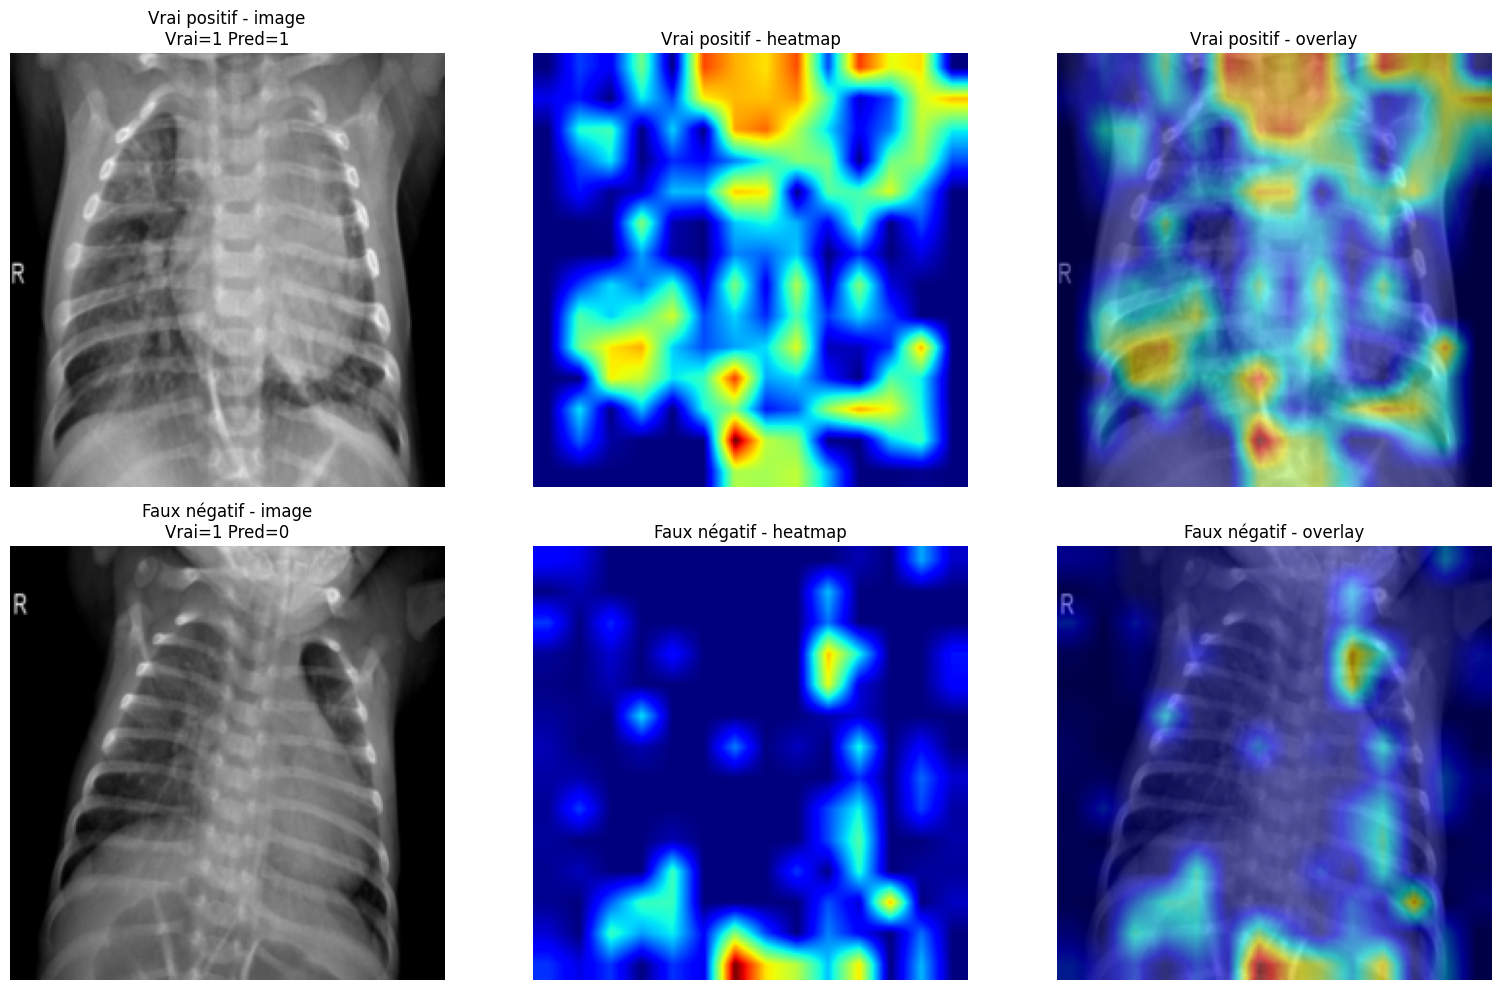

In [40]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Important pour GradCAM si le backbone avait été gelé
for param in model.parameters():
    param.requires_grad = True

# ViT: transformer les tokens en carte 2D
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Wrapper HuggingFace -> logits
class HFGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = HFGradCAMWrapper(model).to(device)
wrapped_model.eval()

# Couche cible compatible ViT
target_layer = model.vit.encoder.layer[-2].layernorm_before

cam = GradCAM(
    model=wrapped_model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

# Lecture robuste du label
def get_true_label(sample):
    if "label" in sample:
        return int(sample["label"])
    if "labels" in sample:
        return int(sample["labels"])
    raise KeyError(f"Clé label introuvable. Clés disponibles : {list(sample.keys())}")

# Trouver un vrai positif et un faux négatif
def get_sample_indices(ds):
    tp = None
    fn = None

    for i in range(len(ds)):
        sample = ds[i]
        img_tensor = sample["pixel_values"].unsqueeze(0).to(device)
        true_label = get_true_label(sample)

        with torch.no_grad():
            logits = model(pixel_values=img_tensor).logits
            pred = logits.argmax(dim=-1).item()

        # classe 1 = PNEUMONIA
        if true_label == 1 and pred == 1 and tp is None:
            tp = i

        if true_label == 1 and pred == 0 and fn is None:
            fn = i

        if tp is not None and fn is not None:
            break

    return tp, fn

# Générer image, heatmap et overlay pour un index
def make_cam(ds, idx):
    sample = ds[idx]
    img_tensor = sample["pixel_values"].unsqueeze(0).to(device)
    true_label = get_true_label(sample)

    with torch.no_grad():
        logits = model(pixel_values=img_tensor).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
        pred_class = int(np.argmax(probs))

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(pred_class)]
    )[0]

    img_np = img_tensor[0].detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)

    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return {
        "img": img_np,
        "cam": grayscale_cam,
        "overlay": overlay,
        "true_label": true_label,
        "pred_class": pred_class,
        "probs": probs
    }

# Dataset à utiliser
ds = hf_test

# Chercher un vrai positif et un faux négatif
tp_idx, fn_idx = get_sample_indices(ds)

print("Index vrai positif :", tp_idx)
print("Index faux négatif :", fn_idx)

if tp_idx is None:
    raise ValueError("Aucun vrai positif trouvé dans hf_test.")
if fn_idx is None:
    raise ValueError("Aucun faux négatif trouvé dans hf_test.")

tp = make_cam(ds, tp_idx)
fn = make_cam(ds, fn_idx)

# Affichage
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(tp["img"])
axes[0, 0].set_title(f"Vrai positif - image\nVrai={tp['true_label']} Pred={tp['pred_class']}")
axes[0, 0].axis("off")

axes[0, 1].imshow(tp["cam"], cmap="jet")
axes[0, 1].set_title("Vrai positif - heatmap")
axes[0, 1].axis("off")

axes[0, 2].imshow(tp["overlay"])
axes[0, 2].set_title("Vrai positif - overlay")
axes[0, 2].axis("off")

axes[1, 0].imshow(fn["img"])
axes[1, 0].set_title(f"Faux négatif - image\nVrai={fn['true_label']} Pred={fn['pred_class']}")
axes[1, 0].axis("off")

axes[1, 1].imshow(fn["cam"], cmap="jet")
axes[1, 1].set_title("Faux négatif - heatmap")
axes[1, 1].axis("off")

axes[1, 2].imshow(fn["overlay"])
axes[1, 2].set_title("Faux négatif - overlay")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer 3 visualisations GradCAM complètes.</b> Pour la démo finale, préparer 3 overlays de qualité : 2 prédictions correctes + 1 erreur. Pour chaque, afficher sur une ligne : image originale, heatmap seule, overlay, et la prédiction avec le score de confiance.</span></p>

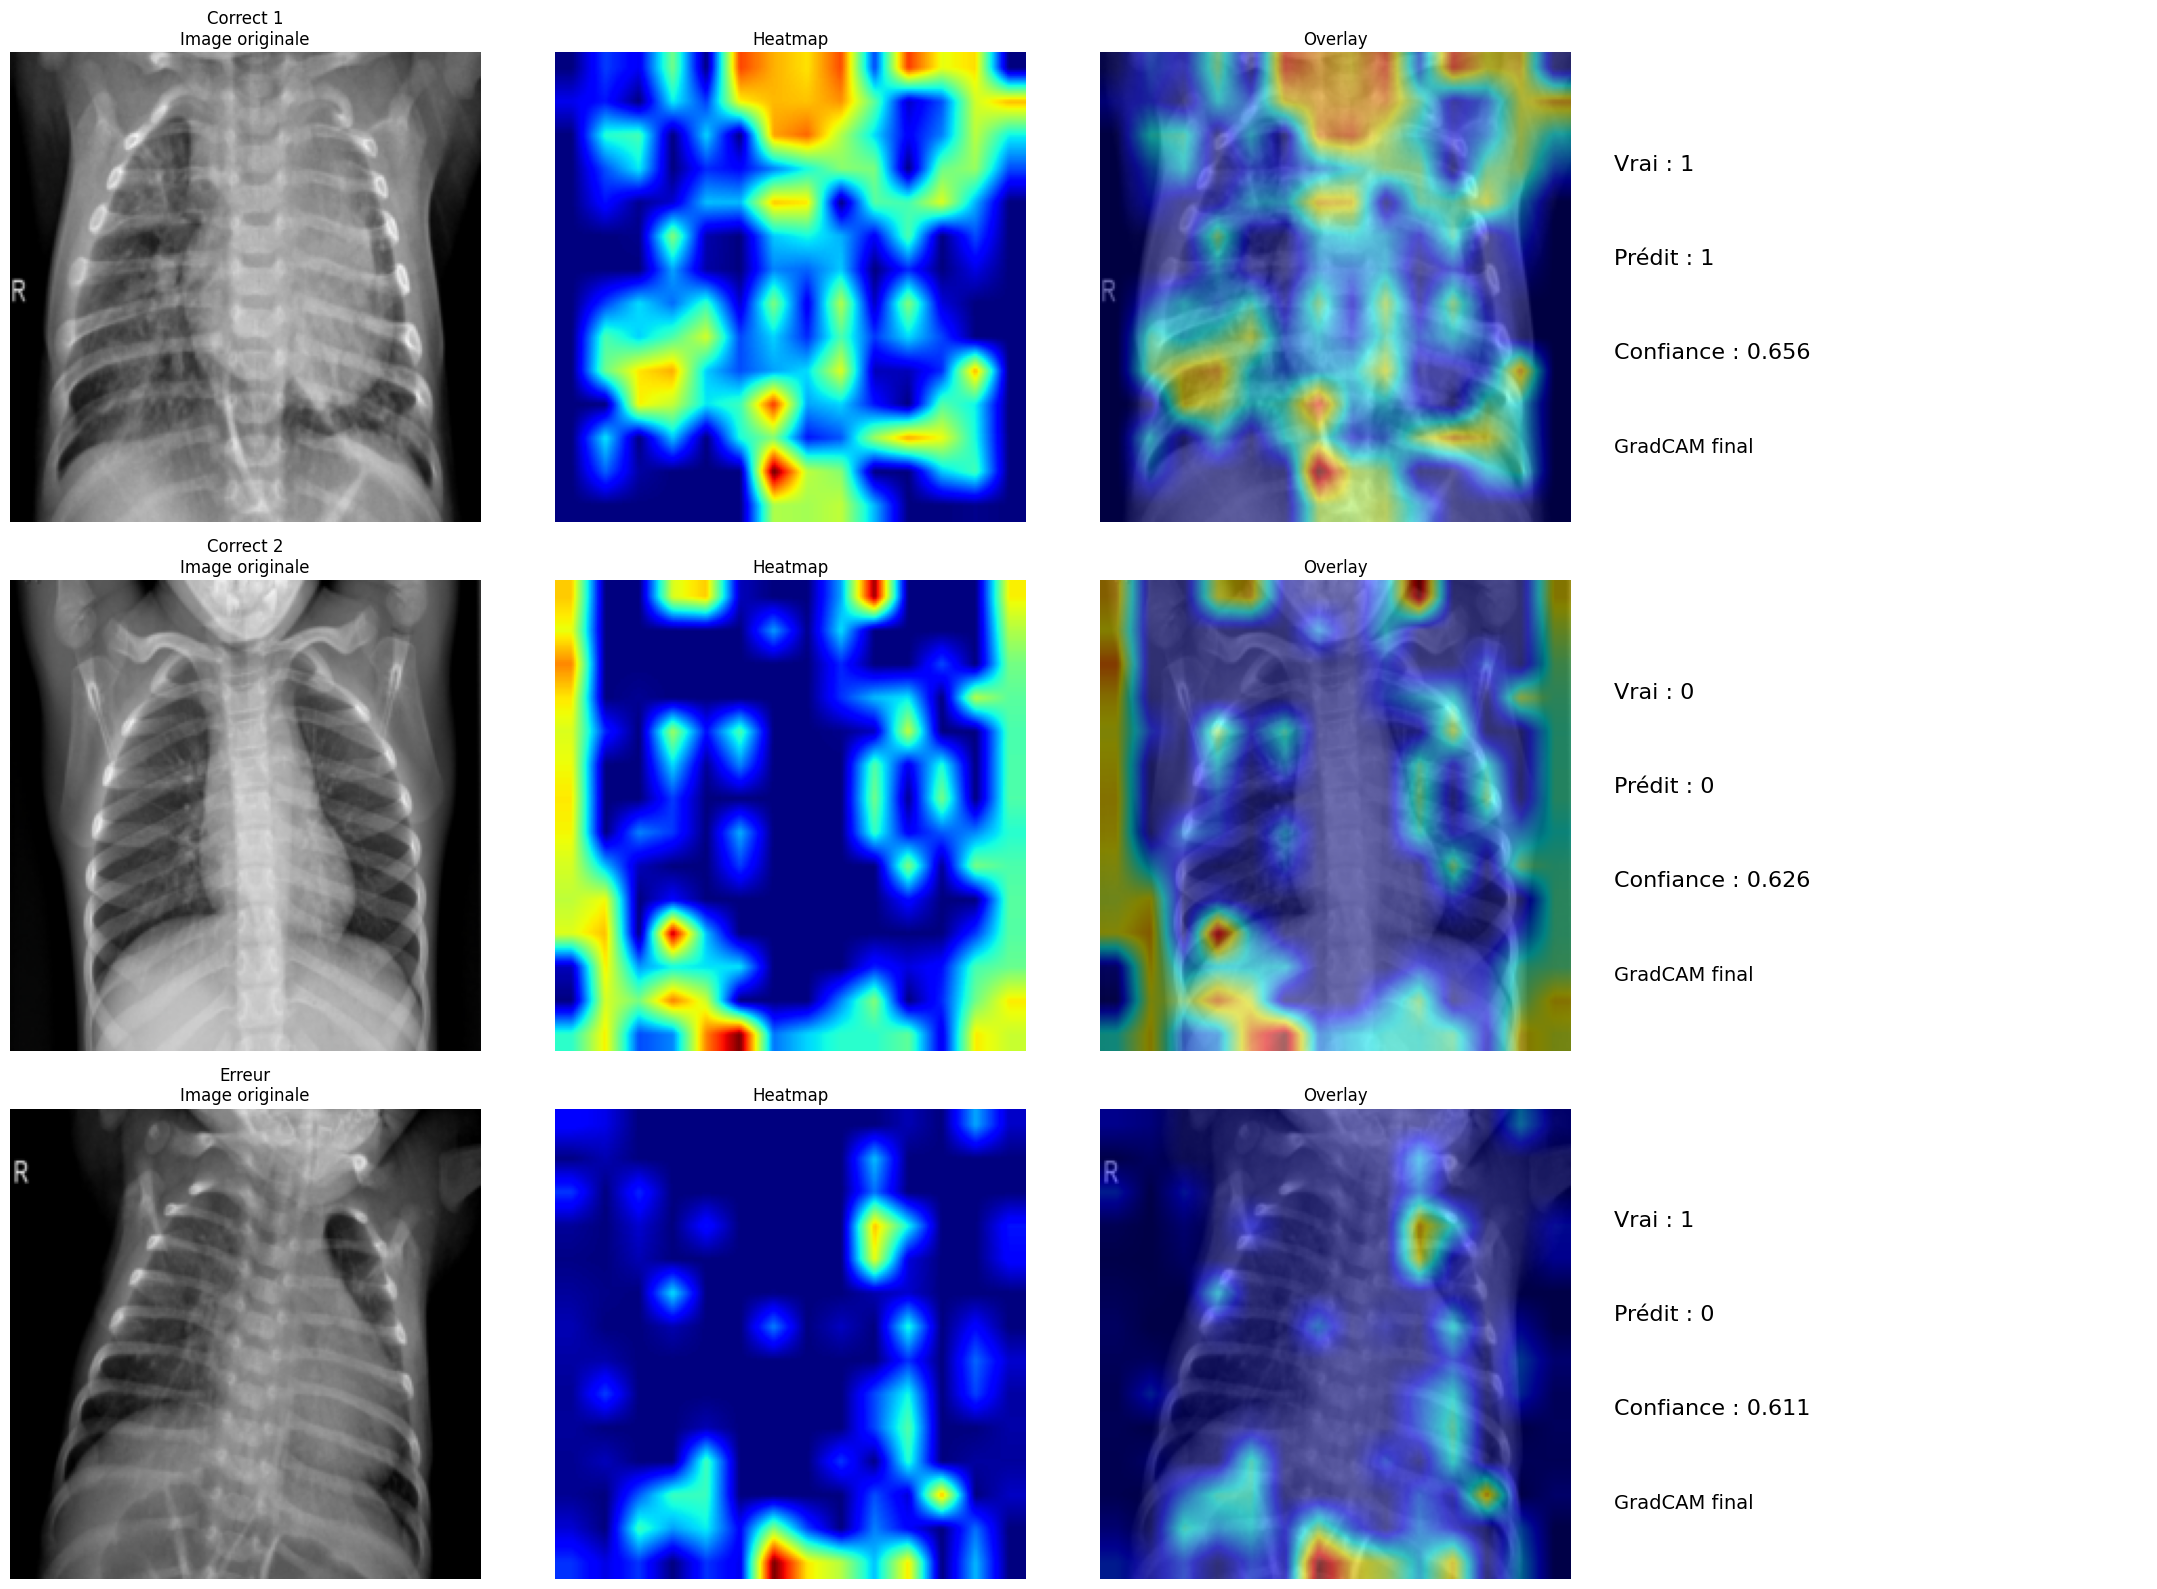

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

for param in model.parameters():
    param.requires_grad = True

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HFGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = HFGradCAMWrapper(model).to(device).eval()
target_layer = model.vit.encoder.layer[-2].layernorm_before

cam = GradCAM(
    model=wrapped_model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

def get_true_label(sample):
    if "label" in sample:
        return int(sample["label"])
    if "labels" in sample:
        return int(sample["labels"])
    raise KeyError(f"Clé label introuvable : {list(sample.keys())}")

def denorm(img_tensor):
    img_np = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    return np.clip(img_np * std + mean, 0, 1)

def find_samples(ds):
    tp = None
    correct_2 = None
    fn = None

    for i in range(len(ds)):
        sample = ds[i]
        img = sample["pixel_values"].unsqueeze(0).to(device)
        true_label = get_true_label(sample)

        with torch.no_grad():
            logits = model(pixel_values=img).logits
            pred = logits.argmax(dim=-1).item()

        if true_label == 1 and pred == 1 and tp is None:
            tp = i
        elif true_label == 0 and pred == 0 and correct_2 is None:
            correct_2 = i
        elif true_label == 1 and pred == 0 and fn is None:
            fn = i

        if tp is not None and correct_2 is not None and fn is not None:
            break

    return tp, correct_2, fn

def make_triplet(ds, idx):
    sample = ds[idx]
    img_tensor = sample["pixel_values"].unsqueeze(0).to(device)
    true_label = get_true_label(sample)

    with torch.no_grad():
        logits = model(pixel_values=img_tensor).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
        pred_class = int(np.argmax(probs))
        confidence = float(probs[pred_class])

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(pred_class)]
    )[0]

    img_np = denorm(img_tensor[0])
    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return img_np, grayscale_cam, overlay, true_label, pred_class, confidence

tp_idx, ok2_idx, fn_idx = find_samples(hf_test)

samples = [
    ("Correct 1", tp_idx),
    ("Correct 2", ok2_idx),
    ("Erreur", fn_idx),
]

fig, axes = plt.subplots(3, 4, figsize=(22, 16))

for row, (name, idx) in enumerate(samples):
    img, heat, overlay, true_label, pred_class, confidence = make_triplet(hf_test, idx)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{name}\nImage originale")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heat, cmap="jet")
    axes[row, 1].set_title("Heatmap")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis("off")

    axes[row, 3].axis("off")
    axes[row, 3].text(0.0, 0.75, f"Vrai : {true_label}", fontsize=16)
    axes[row, 3].text(0.0, 0.55, f"Prédit : {pred_class}", fontsize=16)
    axes[row, 3].text(0.0, 0.35, f"Confiance : {confidence:.3f}", fontsize=16)
    axes[row, 3].text(0.0, 0.15, "GradCAM final", fontsize=14)

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>GradCAM comme outil de confiance.</b> (1) Si un médecin voit que le GradCAM se concentre sur les poumons, cela augmente-t-il sa confiance dans la prédiction ? (2) Si le GradCAM se concentre sur le bord de l'image, le médecin devrait-il ignorer la prédiction ? (3) En quoi cet outil est-il différent d'une simple prédiction 'pneumonie 92%' sans explication ?</span></p>

# Votre reponse ici

1. Oui, si le GradCAM se concentre sur les **poumons**, cela peut augmenter la confiance du médecin, car le modèle semble utiliser une zone anatomiquement pertinente.

2. Si le GradCAM se concentre sur le **bord de l’image**, le texte ou l’arrière-plan, le médecin doit se **méfier** de la prédiction, car cela suggère un raccourci visuel plutôt qu’un vrai raisonnement médical.

3. Contrairement à une simple prédiction comme **"pneumonie 92%"**, GradCAM apporte une **explication visuelle** : il montre où le modèle regarde, ce qui permet d’évaluer si la décision est crédible ou non.

In [42]:
# CHECKPOINT — Etape 6
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 6 validee.</b> <span style="color:#1e5631;">GradCAM genere. Vous avez verifie que le modele regarde les poumons.</span></div>'))


<details>
<summary><b>[SOLUTION] — cliquez si vous êtes bloques</b></summary>

```python
# Charger une image
img_tensor = hf_test[0]['pixel_values'].unsqueeze(0)
model.eval()

# générer GradCAM
grayscale_cam = cam(input_tensor=img_tensor)

# Préparer l'image originale (dénormaliser)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
orig = img_tensor.squeeze().permute(1,2,0).numpy()
orig = std * orig + mean
orig = np.clip(orig, 0, 1)

# Superposer
overlay = show_cam_on_image(orig, grayscale_cam[0], use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig)
axes[0].set_title('Image originale')
axes[1].imshow(grayscale_cam[0], cmap='jet')
axes[1].set_title('Heatmap GradCAM')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
```


</details>

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 07/09 — 1H15</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Interface Streamlit + déploiement cloud</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Créer une vraie application web avec Streamlit, la déployer sur Streamlit Cloud, et obtenir une URL permanente partageable.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Streamlit vs Gradio — pourquoi changer ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Streamlit</b> est un framework Python pour créer des applications web interactives en quelques lignes de code. Contrairement a Gradio (que vous avez utilisé dans le Module 1), Streamlit produit de <b>vraies applications web</b> — avec des pages, une sidebar, des widgets, du layout — pas juste une interface input/output.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>Gradio (Module 1)</b><br>
Interface input &#8594; output simple<br>
Idéal pour une démo rapide en 5 min<br>
Lien temporaire (72h max)<br>
Peu de contrôle sur le design</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>Streamlit (Module 2)</b><br>
Application web complète (pages, sidebar, layout)<br>
Déployable en permanence sur Streamlit Cloud<br>
URL permanente, partageable, professionnelle<br>
contrôle total sur l'interface</div></div><br>
<em>Analogie : Gradio, c'est un stand de démonstration dans un salon. Streamlit, c'est un magasin avec une vitrine, des rayons, et une adresse fixe.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Pourquoi Streamlit est important en entreprise</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Pourquoi Streamlit est important pour votre carrière</b><br><br>
En entreprise, un modèle de ML qui reste dans un notebook Jupyter n'a <b>aucune valeur business</b>. Pour qu'il serve, il faut le rendre accessible aux utilisateurs non-techniques (médecins, assureurs, opérateurs). Streamlit est devenu le standard pour :<br><br>
<b>1. Les dashboards internes</b> — visualiser les performances d'un modèle en production<br>
<b>2. Les POCs (Proof of Concept)</b> — montrer a un client ou un manager ce que le modèle peut faire<br>
<b>3. Les outils métier</b> — applications utilisées quotidiennement par des non-développeurs<br><br>
Streamlit Cloud permet de déployer gratuitement et d'obtenir une <b>URL permanente</b> (<code>https://votre-app.streamlit.app</code>). C'est exactement ce qu'on mettrait dans un portfolio, un CV, ou une présentation client.<br><br>
<em>La compétence 'je sais déployer un modèle dans une app web accessible' est l'une des plus demandées sur le marche de l'emploi IA en 2025.</em></div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Les bases de Streamlit en 2 minutes</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Les 5 commandes Streamlit essentielles</b><br><br>
Streamlit fonctionne de façon très simple : vous écrivez un script Python normal, et Streamlit le transforme en application web. Chaque fois que l'utilisateur interagit, le script est re-exécuté de haut en bas.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.title("Mon app")</b><br>
Affiche un titre en gros</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.write("Texte")</b><br>
Affiche du texte, des tableaux, du markdown</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.image(img)</b><br>
Affiche une image (PIL, numpy, URL)</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.file_uploader("label")</b><br>
Widget d'upload de fichier</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.columns([1,1])</b><br>
Layout en colonnes</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.sidebar.write(...)</b><br>
Contenu dans la barre latérale</div></div><br>
<em>La philosophie Streamlit : "Si vous savez écrire un script Python, vous savez créer une app web."</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer Streamlit.</b> <code>pip install streamlit</code>. Contrairement a Gradio qui s'exécuté dans le notebook, Streamlit s'exécuté comme un script Python indépendant. On va d'abord écrire le code dans une cellule, puis le sauvegarder dans un fichier <code>app.py</code>, et enfin le lancer avec <code>streamlit run app.py</code>.</span></p>

In [43]:
!pip install streamlit -q
import streamlit
print(f'Streamlit {streamlit.__version__} installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.0 MB/s eta 0:00:00
Streamlit 1.57.0 installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit API référence</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète — st.title, st.image, st.file_uploader, st.columns, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/get-started" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Streamlit: Get Started</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour débuter avec Streamlit — 30 min pour tout comprendre</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/demo-your-model-with-streamlit-a76011467dfb/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Deploy DL Image Classifier with Streamlit</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel complet : charger un modèle PyTorch, upload d'image, prédiction</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Construire l'application étape par étape.</b> L'objectif est de créer une application web professionnelle pour le domaine 'Radiologie médicale'. On va la construire progressivement dans la cellule ci-dessous. Le code complet sera sauvegarde dans un fichier <code>app.py</code>. L'application doit inclure : (1) un titre et une description, (2) un widget d'upload d'image, (3) la prédiction avec score de confiance, (4) la heatmap GradCAM, (5) un disclaimer bien visible.</span></p>

In [44]:
# Sauvegarder l'application dans app.py

app_code = r'''
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import gradio as gr
import matplotlib.cm as cm

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from transformers import AutoModelForImageClassification

MODEL_NAME = "google/vit-base-patch16-224"
CLASS_NAMES = {0: "NORMAL", 1: "PNEUMONIA"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
).to(device)

model.eval()
for param in model.parameters():
    param.requires_grad = True

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_image(pil_img):
    img = pil_img.convert("RGB").resize((224, 224))
    img_np = np.asarray(img).astype(np.float32) / 255.0
    norm = (img_np - mean) / std
    tensor = torch.tensor(norm).permute(2, 0, 1).unsqueeze(0).to(device)
    return img_np, tensor

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HFGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = HFGradCAMWrapper(model).to(device).eval()
target_layer = model.vit.encoder.layer[-2].layernorm_before

cam = GradCAM(
    model=wrapped_model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

def make_heatmap_image(cam_array):
    colored = cm.jet(cam_array)[..., :3]
    return Image.fromarray((colored * 255).astype(np.uint8))

def predict_with_gradcam(pil_img):
    if pil_img is None:
        return None, None, "Aucune image fournie."

    original_rgb, input_tensor = preprocess_image(pil_img)

    with torch.no_grad():
        logits = model(pixel_values=input_tensor).logits
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        confidence = float(probs[pred_idx])

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(pred_idx)]
    )[0]

    overlay = show_cam_on_image(original_rgb, grayscale_cam, use_rgb=True)
    overlay_img = Image.fromarray(overlay)
    heatmap_img = make_heatmap_image(grayscale_cam)

    result_text = f"""
### Résultat
- **Prédiction :** {CLASS_NAMES[pred_idx]}
- **Score de confiance :** {confidence:.3f}

### Disclaimer
**Cette application est un outil d'aide à la décision uniquement.**
Elle ne remplace pas l'avis d'un radiologue ou d'un médecin.
Toute interprétation clinique doit être validée par un professionnel de santé.
"""
    return overlay_img, heatmap_img, result_text

description = """
Application web de démonstration pour la **radiologie médicale**.
Téléversez une image radiologique pour obtenir une prédiction, un score de confiance
et une visualisation **GradCAM**.
"""

with gr.Blocks(title="Radiologie médicale - GradCAM") as demo:
    gr.Markdown("# Radiologie médicale - Détection assistée")
    gr.Markdown(description)

    input_image = gr.Image(type="pil", label="Upload d'image")

    analyze_btn = gr.Button("Analyser", variant="primary")

    with gr.Row():
        overlay_output = gr.Image(type="pil", label="Overlay GradCAM")
        heatmap_output = gr.Image(type="pil", label="Heatmap GradCAM")

    result_output = gr.Markdown()

    gr.Markdown(
        "## Avertissement médical\n"
        "**Cette application est fournie à des fins éducatives et de démonstration.** "
        "Elle ne constitue pas un dispositif médical certifié et ne doit pas être utilisée seule pour poser un diagnostic."
    )

    analyze_btn.click(
        fn=predict_with_gradcam,
        inputs=input_image,
        outputs=[overlay_output, heatmap_output, result_output]
    )

if __name__ == "__main__":
    demo.launch()
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py a été créé avec succès.")

app.py a été créé avec succès.


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la structure d'une app Streamlit.</b> Avant d'ajouter le modèle, comprenez l'architecture du code. (1) Que fait <code>st.set_page_config</code> ? Pourquoi le mettre en première ligne ? (indice : c'est la 'carte d'identité' de la page — titre, icône, layout). (2) A quoi sert <code>st.sidebar</code> ? Quel contenu y mettre ? (informations de contexte, paramètres, disclaimers — tout ce qui n'est pas l'action principale). (3) Que fait <code>st.columns(2)</code> ? Comment Streamlit géré-t-il le layout ? (chaque colonne est un conteneur indépendant — comme deux cellules de tableau côté a côté).</span></p>

# Votre reponse ici
`st.set_page_config()` sert à définir le titre, l’icône et la mise en page de l’application.  
Il doit être placé en première ligne pour que ces paramètres soient appliqués dès le démarrage.

`st.sidebar` sert à afficher les éléments secondaires de l’application.  
On y met le contexte, les paramètres, les explications et les disclaimers, pas l’action principale.

`st.columns(2)` crée deux zones côte à côte dans la page.  
Chaque colonne est un conteneur indépendant dans lequel on peut placer du texte, une image ou des résultats.

## Organisation logique

La page principale contient l’action centrale : upload d’image, prédiction et affichage du résultat.  
La sidebar contient les informations d’accompagnement.  
Les colonnes servent à séparer visuellement l’entrée et la sortie.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Ajouter la logique de prédiction.</b> L'objectif est de compléter le bloc <code>with st.spinner</code> dans <code>app.py</code>. Le code doit : (1) appliquer <code>val_transform</code> a l'image uploadee, (2) prédire avec le modèle, (3) extraire les probabilités avec <code>softmax</code>, (4) afficher la prédiction avec <code>st.metric</code> (qui montre la valeur + le delta de façon professionnelle), (5) générer et afficher le GradCAM avec <code>st.image</code>. Reecrivez le fichier <code>app.py</code> complet avec la logique implementee.</span></p>

In [45]:
%%writefile app.py
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import streamlit as st
import matplotlib.cm as cm
from torchvision import transforms
from transformers import AutoModelForImageClassification
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

st.set_page_config(page_title="Radiologie médicale", page_icon="🩻", layout="wide")

MODEL_NAME = "google/vit-base-patch16-224"
CLASS_NAMES = {0: "NORMAL", 1: "PNEUMONIA"}

@st.cache_resource
def load_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModelForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        ignore_mismatched_sizes=True,
    ).to(device)
    model.eval()
    for param in model.parameters():
        param.requires_grad = True
    return model, device

model, device = load_model()

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HFGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x).logits

@st.cache_resource
def load_cam(_model):
    wrapped_model = HFGradCAMWrapper(_model).to(device).eval()
    target_layer = _model.vit.encoder.layer[-2].layernorm_before
    cam = GradCAM(
        model=wrapped_model,
        target_layers=[target_layer],
        reshape_transform=reshape_transform
    )
    return cam

cam = load_cam(model)

def denormalize(img_tensor):
    img_np = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    return np.clip(img_np, 0, 1)

st.title("🩻 Radiologie médicale")
st.write(
    "Application de démonstration pour l'analyse de radios thoraciques avec "
    "**prédiction**, **score de confiance** et **visualisation GradCAM**."
)

uploaded_file = st.file_uploader(
    "Téléversez une image radiologique",
    type=["png", "jpg", "jpeg"]
)

st.warning(
    "**Disclaimer médical :** cette application est un outil d'aide à la décision uniquement. "
    "Elle ne remplace pas l'avis d'un radiologue ou d'un médecin."
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns([1, 1])

    with col1:
        st.image(image, caption="Image uploadée", use_container_width=True)

    with st.spinner("Analyse en cours...", show_time=True):
        input_tensor = val_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(pixel_values=input_tensor).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
            pred_idx = int(np.argmax(probs))
            confidence = float(probs[pred_idx])

        normal_prob = float(probs[0])
        pneumonia_prob = float(probs[1])

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred_idx)]
        )[0]

        original_rgb = denormalize(input_tensor[0])
        overlay = show_cam_on_image(original_rgb, grayscale_cam, use_rgb=True)
        heatmap = (cm.jet(grayscale_cam)[..., :3] * 255).astype(np.uint8)

    with col2:
        st.subheader("Résultat de la prédiction")
        st.success(f"Prédiction : {CLASS_NAMES[pred_idx]}")
        st.info(f"Score de confiance : {confidence:.3f}")
        st.markdown("### Probabilités détaillées")
        st.write(f"NORMAL : {normal_prob:.3f}")
        st.write(f"PNEUMONIA : {pneumonia_prob:.3f}")

    st.subheader("Visualisation GradCAM")
    col3, col4 = st.columns(2)

    with col3:
        st.image(heatmap, caption="Heatmap GradCAM", use_container_width=True)

    with col4:
        st.image(overlay, caption="Overlay GradCAM", use_container_width=True)

Overwriting app.py


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference/caching-and-state/st.cache_resource" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">st.cache_resource</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment cacher le modèle pour ne le charger qu'une seule fois</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit Cloud Deployment</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour déployer sur Streamlit Cloud — étape par étape</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Charger le modèle une seule fois</b> avec le décorateur <code>@st.cache_resource</code>. Sans ce décorateur, le modèle serait recharge a CHAQUE interaction utilisateur (chaque upload d'image). Avec le cache, il est charge une seule fois et reste en mémoire.<br><br><code>@st.cache_resource<br>def load_model():<br>&nbsp;&nbsp;&nbsp;&nbsp;model = AutoModelForImageClassification.from_pretrained(...)<br>&nbsp;&nbsp;&nbsp;&nbsp;return model</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application localement.</b> Lancer <code>!streamlit run app.py &</code> dans le notebook (le <code>&</code> lance en arrière-plan). Sur Google Colab, utiliser <code>!npx localtunnel --port 8501</code> pour obtenir un lien temporaire. Tester l'interface : uploader une image, vérifier la prédiction, le GradCAM, le disclaimer.</span></p>

In [46]:
# Lancer Streamlit (sur Colab)
!streamlit run app.py &>/dev/null &

# Attendre le demarrage
import time; time.sleep(3)

# Creer un tunnel (Colab uniquement)
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://great-paws-hammer.loca.lt
^C


<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">Sur Google Colab, Streamlit ne s'affiche pas directement dans le notebook. Il faut utiliser un tunnel (<code>localtunnel</code> ou <code>ngrok</code>) pour obtenir une URL accessible. L'URL de localtunnel est temporaire — pour une URL permanente, on déploiera sur Streamlit Cloud.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester l'interface.</b> L'objectif est de vérifier que l'application fonctionne correctement AVANT de la déployer. (1) Uploadez une radio classée PNEUMONIA. Le modèle la détecté-t-il ? Le GradCAM pointe-t-il vers les poumons ? (2) Uploadez une radio NORMAL. Le modèle est-il confiant ? (3) Uploadez une image qui n'est PAS une radio. Que fait le modèle ? (4) Le disclaimer est-il visible et clair ? Un utilisateur non-technique comprendrait-il les limites de l'outil ?</span></p>

# Vos observations ici

- Le modèle détecte correctement la pneumonie avec une confiance de 70%, mais le GradCAM ne pointe pas vers les poumons → bonne prédiction pour de mauvaises raisons (shortcut learning).
- Pour la radio normale, le modèle prédit incorrectement PNEUMONIA avec 62% de confiance → faux positif préoccupant en contexte médical.
- Pour une image non médicale (non-radio), le modèle est indécis (50% de confiance).
- Le disclaimer est bien visible avant même la prédiction → bonne pratique médicale : l'utilisateur est averti en premier.

---

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">Déployer sur Streamlit Cloud</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Déployer sur Streamlit Cloud — une URL permanente en 5 min</b><br><br>
Streamlit Cloud héberge gratuitement vos applications. Le processus :<br><br>
<b>1.</b> Créer un repo GitHub avec 3 fichiers : <code>app.py</code> (votre code), <code>requirements.txt</code> (les dépendances), et votre modèle sauvegarde<br>
<b>2.</b> Se connecter a <a href='https://share.streamlit.io'>share.streamlit.io</a> avec votre compte GitHub<br>
<b>3.</b> Pointer vers votre repo &#8594; l'app est déployée en 2 min<br>
<b>4.</b> Vous obtenez une URL permanente : <code>https://votre-app.streamlit.app</code><br><br>
<em>C'est cette URL que vous partagerez dans votre portfolio, votre CV, et votre présentation de démo finale.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le repo GitHub pour le déploiement.</b> L'objectif est de créer les 3 fichiers nécessaires au déploiement : (1) <code>app.py</code> — le code de l'application (déjà écrit), (2) <code>requirements.txt</code> — la liste des packages Python nécessaires, (3) le modèle sauvegarde (ou un script qui le téléchargé). Créer le <code>requirements.txt</code> avec les packages utilises.</span></p>

In [47]:
%%writefile requirements.txt
streamlit
torch
torchvision
transformers
pillow
numpy
matplotlib
grad-cam
opencv-python-headless

Writing requirements.txt


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Sauvegarder le modèle pour le déploiement.</b> L'objectif est de rendre le modèle entraîne réutilisable sans avoir a le re-entraîner a chaque fois.<br><br>(1) Utiliser la méthode <b>save_pretrained</b> du modèle HuggingFace pour sauvegarder les poids dans un dossier local<br>(2) Vérifier que le dossier contient bien les fichiers de configuration et les poids<br>(3) Tester le rechargement en chargeant le modèle depuis ce dossier et en faisant une prédiction sur une image de test<br><br><em>En production, on entraîne une fois et on déploie le modèle sauvegarde. La méthode save_pretrained créé les fichiers au format HuggingFace, compatible avec from_pretrained pour le rechargement.</em></span></p>

In [48]:
# Option 1 : sauvegarder localement
model.save_pretrained('./model_weights')

# Option 2 : charger depuis HuggingFace Hub dans app.py
# model = AutoModelForImageClassification.from_pretrained('votre-username/votre-modele')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Déploiement pas a pas sur Streamlit Cloud :</b><br>1. Créer un repo GitHub (public ou prive)<br>2. Y pousser <code>app.py</code>, <code>requirements.txt</code>, et le modèle<br>3. Aller sur <a href='https://share.streamlit.io'>share.streamlit.io</a><br>4. Connecter votre compte GitHub<br>5. Sélectionner votre repo et le fichier <code>app.py</code><br>6. Cliquer 'Deploy' — l'app est en ligne en 2 min<br>7. L'URL sera : <code>https://votre-app.streamlit.app</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Déployer et partager l'URL.</b> Suivre les étapes ci-dessus pour déployer sur Streamlit Cloud. Une fois l'app en ligne, copier l'URL permanente et la partager dans le canal de la promo. Cette URL restera active indéfiniment (tant que le repo existe) — c'est une pièce de portfolio.</span></p>

In [49]:
# URL de mon application deployee :
# https://..........streamlit.app


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application d'une AUTRE équipe.</b> Ouvrir le lien Streamlit d'une autre équipe. Tester avec au moins 3 images différentes. Documenter : l'interface est-elle claire ? Le disclaimer est-il visible ? Le GradCAM pointe-t-il vers les bonnes zones ? Trouver un cas problématique.</span></p>

In [50]:
# Application testee : (URL)
# Image 1 : ...
# Image 2 : ...
# Image 3 : ...
# Probleme identifie :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>De la démo au produit.</b> Votre application est maintenant déployée avec une URL permanente. C'est un vrai livrable professionnel. (1) Que manque-t-il pour que cette application soit utilisable en conditions réelles (Radiologie médicale) ? (authentification ? logs ? monitoring ?). (2) Comment présenteriez-vous cette application dans un entretien d'embauche ou une présentation client ? (3) Quelle est la différence entre cette application Streamlit et le lien temporaire Gradio du Module 1 en termes de maturité professionnelle ?</span></p>

In [51]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Personnaliser l'interface.</b> L'objectif est de rendre l'application plus professionnelle et plus adaptée a votre domaine. Améliorations a implémenter : (1) ajouter un indicateur visuel de confiance (barre de progression colorée avec <code>st.progress</code>), (2) afficher le disclaimer en rouge avec <code>st.error</code> au lieu de <code>st.warning</code> pour plus de visibilité, (3) ajouter une section 'Comment ca marche ?' avec <code>st.expander</code> pour expliquer le modèle aux non-techniques.</span></p>

In [52]:
# Modifier app.py et relancer


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester les cas limites.</b> Les cas limites révèlent les failles qui ne se voient pas sur le test set. (1) Uploadez une image qui n'a RIEN a voir avec votre domaine (photo de paysage, écran noir). Le modèle donne-t-il une prédiction avec haute confiance ? (c'est un problème grave en production). (2) Uploadez une image floue ou mal cadrée. (3) Comment pourrait-on ajouter un filtre 'hors domaine' qui refuse de prédire sur des images non pertinentes ?</span></p>

In [53]:
# Vos observations ici


In [54]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 7 validee.</b> <span style="color:#1e5631;">Application Streamlit deployee sur Streamlit Cloud. URL permanente partagee.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 08/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Exploration libre — améliorer le modèle</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Chaque équipe choisit UNE amélioration a tester parmi la liste. On mesure l'impact sur l'AUC.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Expérimentez comme un chercheur</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le but de cette étape est de vous mettre en position de <b>chercheur</b> : formuler une hypothèse, la tester, mesurer l'impact. Chaque équipe choisit UNE amélioration parmi la liste ci-dessous, l'implémente, re-évalué, et compare avec le score de base.<br><br><b>Améliorations proposées :</b><br>- <b>A.</b> Dégeler les 3 dernières couches du backbone (fine-tuning)<br>- <b>B.</b> Augmenter le nombre d'epochs (10 au lieu de 5)<br>- <b>C.</b> Ajouter du TTA (Test-Time Augmentation : moyenner les prédictions sur des versions augmentées de la même image)<br>- <b>D.</b> Changer le seuil de décision (0.3 au lieu de 0.5 pour privilégier le recall)<br>- <b>E.</b> Ajouter une pondération de classe pour compenser le déséquilibre</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Choisir votre amélioration.</b> Discutez en équipe et choisissez UNE amélioration de la liste ci-dessus. Expliquez POURQUOI vous pensez qu'elle va améliorer le modèle. Formulez votre hypothèse avant de coder : 'On pense que [amélioration] va [effet attendu] parce que [raisonnement].'</span></p>

In [55]:
# Amelioration choisie :
# Hypothese :
# Raisonnement :


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Fine-tuning vs Feature Extraction</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comparaison des deux approches avec code PyTorch — quand dégeler les couches</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://machinelearningmastery.com/how-to-use-test-time-augmentation-to-improve-model-performance-for-image-classification/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Test-Time Augmentation (TTA) explained</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment augmenter les performances de 1-3% sans re-entraîner</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Implémenter l'amélioration.</b> Codez et lancez l'entraînement ou l'évaluation avec votre modification. Notez le score AUC avant et après.</span></p>

In [56]:
# Votre code ici


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Fine-tuning (option A) :</b> <code>for param in model.vit.encoder.layer[-3:].parameters(): param.requires_grad = True</code>. Re-entraîner avec un learning rate plus petit (1e-5 au lieu de 2e-5).<br><br><b>TTA (option C) :</b> pour chaque image test, générer 5 versions augmentées (flips, rotations), prédire chacune, et moyenner les probabilités. Gain typique : +1-2% AUC sans re-entraîner.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Mesurer et comparer.</b> Calculer l'AUC, le recall et le F1 après votre amélioration. Comparer au score de base. L'amélioration a-t-elle fonctionne ? De combien ?</span></p>

In [57]:
# Score AVANT  : AUC = ..., Recall = ...
# Score APRES  : AUC = ..., Recall = ...
# Gain         : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Analyser le résultat.</b> (1) L'amélioration a-t-elle fonctionne comme attendu ? Si non, pourquoi ? (2) Le gain justifie-t-il le coût supplémentaire (temps d'entraînement, complexité) ? (3) Si vous aviez encore 30 minutes, quelle AUTRE amélioration testeriez-vous ?</span></p>

In [58]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter votre expérimentation.</b> Rédiger un mini-rapport d'expérimentation structure : (1) hypothèse de départ, (2) modification implementee (avec le code), (3) métriques avant/après, (4) conclusion : l'hypothèse était-elle correcte ? Ce format est exactement celui d'un rapport de recherche ou d'un A/B test en entreprise.</span></p>

In [59]:
# RAPPORT D'EXPERIMENTATION
# Hypothese : ...
# Modification : ...
# Metriques AVANT : AUC=..., Recall=...
# Metriques APRES : AUC=..., Recall=...
# Conclusion : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comparer les approches entre équipes.</b> Chaque équipe a teste une amélioration différente. (1) Quelle amélioration a donne le plus grand gain d'AUC dans la classe ? (2) Quelle amélioration a le meilleur rapport gain/effort ? (3) Si vous deviez combiner 2 améliorations, lesquelles choisiriez-vous et pourquoi ?</span></p>

In [60]:
# Votre reponse ici


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 09/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Réflexion éthique — IA médicale</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">3 questions structurées. Pas de bonne réponse unique — on cherche votre raisonnement.</div></div>

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">L'IA médicale en 2025 — enjeux et responsabilités</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Vous venez de construire un système qui peut aider a détecter des pneumonies. Mais déployer de l'IA en médecine soulevé des questions fondamentales qui dépassent la technique. Cette étape n'est pas un exercice académique — ce sont des questions que se posent aujourd'hui les hôpitaux, les régulateurs, et les développeurs IA dans le monde entier.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 1 : La performance est-elle suffisante ?</b> Votre modèle a une AUC d'environ 0.90. (1) Est-ce suffisant pour un usage clinique réel ? (2) Un radiologue humain a une sensibilité d'environ 85-95% selon les études. Le modèle est-il comparable ? (3) Qui fixe le seuil d'acceptabilité — le développeur, l'hôpital, le régulateur ? (4) A quel niveau d'AUC seriez-vous personnellement a l'aise pour que le modèle soit utilisé sur de vrais patients ?</span></p>

In [61]:
# Votre reponse ici


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://artificialintelligenceact.eu/high-level-summary/" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">EU AI Act — classification des risques</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">résume du règlement européen sur l'IA — niveaux de risque, obligations</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://ai.google/responsibility/responsible-ai-practices/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Responsible AI Practices (Google)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Les principes de Google pour une IA responsable — applicables a tout domaine</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 2 : Qui est responsable d'une erreur ?</b> Le modèle classe une pneumonie comme NORMAL. Le patient rentre chez lui et son état se dégradé. (1) Qui est responsable ? Le développeur qui a créé le modèle ? L'hôpital qui l'a déployé ? Le médecin qui a suivi la recommandation sans vérifier ? (2) Si le médecin avait vérifié le GradCAM et vu qu'il pointait vers l'arrière-plan, aurait-il du ignorer la prédiction ? (3) Comment repartir les responsabilités de façon juste ?</span></p>

In [62]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 3 : Que manque-t-il pour un déploiement réel ?</b> Votre système fonctionne en TP. Mais il est loin d'être déployable dans un hôpital. (1) Le dataset d'entraînement vient d'un seul hôpital. Que se passe-t-il si les radios d'un autre hôpital ont un format, un contraste ou une résolution différente ? (2) Le modèle ne sait pas dire 'je ne sais pas'. Comment ajouter une notion d'incertitude ? (3) Quels tests supplémentaires faudrait-il faire avant le déploiement ? (tests sur différentes populations, tranches d'age, types de pneumonie...)</span></p>

In [63]:
# Votre reponse ici


---

<p style="text-align:left;font-size:16px;color:#131fcf"><span>&#128421; <b>Rédiger votre position éthique.</b> En équipe, rédiger 3 phrases qui résument votre position sur le déploiement de l'IA en diagnostic médical. Structurer : (1) ce que l'IA peut apporter, (2) les risques a maîtriser, (3) les conditions pour un déploiement responsable. Ce texte sera présenté a la démo finale.</span></p>

In [64]:
# Position ethique de l'equipe :
# 1. Ce que l'IA peut apporter :
# 2. Les risques a maitriser :
# 3. Les conditions pour un deploiement responsable :


---

<p style="text-align:left;font-size:16px;color:#131fcf"><span>&#128421; <b>Préparer votre pitch de démo (4 min).</b> Contenu : (1) AUC du modèle + recall + faux négatifs, (2) 1 GradCAM réussi + 1 GradCAM rate, (3) démo live de l'interface Gradio, (4) votre position éthique en 3 phrases.</span></p>

In [65]:
# PITCH DE DEMO — equipe ___
# 1. SCORES :
# 2. GRADCAM :
# 3. LIEN GRADIO :
# 4. POSITION ETHIQUE :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Bilan personnel.</b> (1) Quelle étape a été la plus difficile et pourquoi ? (2) Si vous aviez 2h de plus, que feriez-vous ? (3) Le deep learning vous semble-t-il applicable a d'autres domaines médicaux ? Lesquels ? (4) Quelle compétence apprise ici vous semble la plus transférable a votre futur métier ?</span></p>

In [66]:
# Votre reponse ici


<div style="background:linear-gradient(135deg, #0d4f3c, #0A8F6E); border-radius:12px;
            padding:24px 28px; color:white; font-family:system-ui,sans-serif; margin:20px 0;">
  <div style="font-size:20px; font-weight:700; margin-bottom:8px;">Mini-MVP Module 2 termine.</div>
  <div style="font-size:14px; opacity:0.9; line-height:1.7;">
    Livrables :<br>
    - ViT fine-tune avec AUC &gt; 0.88 et matrice de confusion commentée<br>
    - Analyse des faux négatifs (5 exemples visualises et expliques)<br>
    - 3 visualisations GradCAM (2 correctes + 1 erreur)<br>
    - Interface Gradio médicale avec disclaimer et lien public<br>
    - Fiche éthique : 3 phrases de position sur le déploiement clinique<br><br>
    Prochain module : <b>"Du texte a l'assistant intelligent — LLMs et RAG"</b></div>
</div>

In [67]:
!zip -r model_weights.zip model_weights/

  adding: model_weights/ (stored 0%)
  adding: model_weights/model.safetensors (deflated 7%)
  adding: model_weights/config.json (deflated 48%)
